# Covering factor per ogni linea e per ogni blazar e poi stima della LBLR
In questo notebook:
1) calcolo il covering factor di ogni linea  
2) calcolo la luminosità della BLR di ciascun blazar pesando le righe secondo Vanden Berk

## 1 Calcolo del covering factor:  
- assumo che le masse siano in primo passaggio 5*10^8 masse solari, poi 10^9 masse solari; per ciascuno dei due casi modellizzo l'emissione dal disco di accrescimento ponenedo lambda_edd=1% e poi 10%
- calcolo L_line di ogni riga presente
- faccio i calcoli per ogni balzar
- calcolo per ogni blazar il covering factor di ogni linea di emissione facendo : C_f= L_line/L_ion

### 1.1 Costanti e parametri

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Costanti fisiche in cgs
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5 #costante di Stefan-Boltzmann
Msun = 1.98847e33

# Parametri del modello
eta = 0.083
Nr = 2000
Nnu = 400
nu_min = 1e13
nu_max = 1e17

# File input
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

In [2]:
# Casi possibili per MBH e lambda_edd
SCENARI = [
    {"scenario": "MBH_5e8_lambda_0.01", "MBH_solar": 5e8, "lambda_edd": 0.01},
    {"scenario": "MBH_5e8_lambda_0.1",  "MBH_solar": 5e8, "lambda_edd": 0.1},
    {"scenario": "MBH_1e9_lambda_0.01", "MBH_solar": 1e9, "lambda_edd": 0.01},
    {"scenario": "MBH_1e9_lambda_0.1",  "MBH_solar": 1e9, "lambda_edd": 0.1},]

### 1.2 Funzioni utili

In [3]:
# funzione per trovare la colonna in un DataFrame dato un elenco di possibili nomi
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None

In [4]:
# funzione per costruire lo spettro del disco dal modello di Shakura-Sunyaev
#def costruisci_spettro_disco(MBH_solar, eta=0.083, lambda_edd=0.1, Nr=2000, Nnu=400, nu_min=1e13, nu_max=1e17):
def costruisci_spettro_disco(MBH_solar, lambda_edd, eta=0.083, Nr=2000, Nnu=400, nu_min=1e13, nu_max=1e17):
    """
    Costruisce lo spettro del disco per una massa MBH_solar [Msun] e un rapporto di Eddington lambda_edd.
    Restituisce nu, Lnu, nuLnu e un dizionario con i parametri fisici principali.
    """
    MBH = MBH_solar * Msun
    Ledd = 1.3e38 * MBH_solar
    Ldisk = lambda_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = { "MBH_solar": MBH_solar, "Ledd": Ledd, "Ldisk": Ldisk, "Mdot": Mdot, "Rs": Rs, "Rin": Rin, "Rout": Rout}
    return nu, Lnu, nuLnu, info

In [5]:
# funzione per leggere il file delle transizioni
def leggi_transizioni(file_transizioni):
    """
    Legge dati.asc con 3 colonne:
    nome_transizione   E_ion   nu_ion
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=('U50', float, float),
        unpack=True)

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list})

In [ ]:
# funzione per calcolare L_ion per ogni transizione
def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=1e17):
    """
    Calcola L_ion = integral_{nu_ion}^{nu_max} Lnu dnu per ogni transizione.
    """
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]
        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:  # prendo almeno 2 punti per l'integrazione
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion})

    return pd.DataFrame(risultati)

In [7]:
# funzione per estrarre le linee osservate positive da una riga del dataframe
def estrai_linee_osservate(row, norm_columns):
    """
    Estrae le linee osservate positive da una riga del dataframe.
    """
    risultati = []

    for col in norm_columns:
        valore = row[col]
        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line": L_line})

    return pd.DataFrame(risultati)

In [8]:
# funzione per fare il grafico dello spettro con le linee di ionizzazione
def fai_grafico_spettro(nu, Lnu, df_lion, nome_blazar, scenario_name):
    plt.figure(figsize=(8, 6))
    plt.loglog(nu, Lnu, color="black", lw=2, label="Lnu disco")

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % cmap.N) for i in range(len(df_lion))]

    for (_, row), col in zip(df_lion.iterrows(), colors):
        plt.axvline(row["nu_ion"], color=col, lw=1.4, alpha=0.8, label=row["line_name"])

    plt.xlabel("nu [Hz]")
    plt.ylabel("Lnu [erg s^-1 Hz^-1]")
    plt.title(f"Spettro del disco - {nome_blazar} - {scenario_name}")
    plt.xlim(nu.min(), nu.max())
    #limite siu y da 10^17 fino a 10^30
    plt.ylim(1e17, 1e30)
    plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

In [9]:
# Lettura dei file e preparazione dei dati
df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)
#print("Colonne in Tab_completa_revisione.csv:")
#print(df_tab.columns.tolist())

#print("\nPrime transizioni lette da dati.asc:")
#display(df_trans.head())

# Identificazione delle colonne utili
col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

#print("Colonna nome in tabella linee:", col_name_tab)
#print("Colonne di linea trovate:")
#print(norm_columns)

# Base dei dati: solo tabella linee
df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()
#print(f"Blazar trovati: {len(df_all)}")
#display(df_all[["label"]].head())

### 1.3 Funzione analisi singolo blazar (con esempio di blazar in 1 scenario)

In [10]:
# ANALISI DI UN SINGOLO BLAZAR

def analizza_blazar(row, df_trans, norm_columns, mostra_grafico=True):
    nome_blazar = row["label"]
    MBH_solar = row["MBH_solar"]
    lambda_edd = row["lambda_edd"]
    scenario_name = row["scenario"]
    redshift = row["redshift"] if "redshift" in row.index else np.nan

    print("=" * 80)
    print(f"Scenario = {scenario_name}")
    print(f"Blazar: {nome_blazar}")
    print(f"redshift = {redshift}")
    print(f"MBH = {MBH_solar:.3e} Msun")
    print(f"lambda_edd = {lambda_edd:.3f}")

    # spettro disco
    nu, Lnu, nuLnu, info = costruisci_spettro_disco(
        MBH_solar=MBH_solar,
        eta=eta,
        lambda_edd=lambda_edd,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max)

    print(f"Ledd  = {info['Ledd']:.3e} erg/s")
    print(f"Ldisk = {info['Ldisk']:.3e} erg/s")
    print(f"Mdot  = {info['Mdot']:.3e} g/s")

    # L_ion teoriche
    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=nu_max)

    #print("\nLuminosità di ionizzazione del modello:")
    #display(df_lion)

    # linee osservate
    df_linee = estrai_linee_osservate(row, norm_columns)

    print("\nLinee osservate del blazar:")
    display(df_linee)

    # merge e covering factor
    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[(df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0), "covering_factor"] = np.nan

    print("\nConfronto finale per ogni linea:")
    display(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

    if mostra_grafico:
        fai_grafico_spettro(nu, Lnu, df_lion, nome_blazar, scenario_name)

    return df_conf

Scenario = MBH_5e8_lambda_0.01
Blazar: J1745.6
redshift = 0.078
MBH = 5.000e+08 Msun
lambda_edd = 0.010
Ledd  = 6.500e+46 erg/s
Ldisk = 6.500e+44 erg/s
Mdot  = 8.714e+24 g/s

Linee osservate del blazar:


,line_name,norm_value,L_line
0,Ha,3.631777,3.631777e+42
1,Hb,1.103068,1.103068e+42



Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,Ha,3.631777e+42,5.287321e+44,0.006869
1,Hb,1.103068e+42,4.781810e+44,0.002307


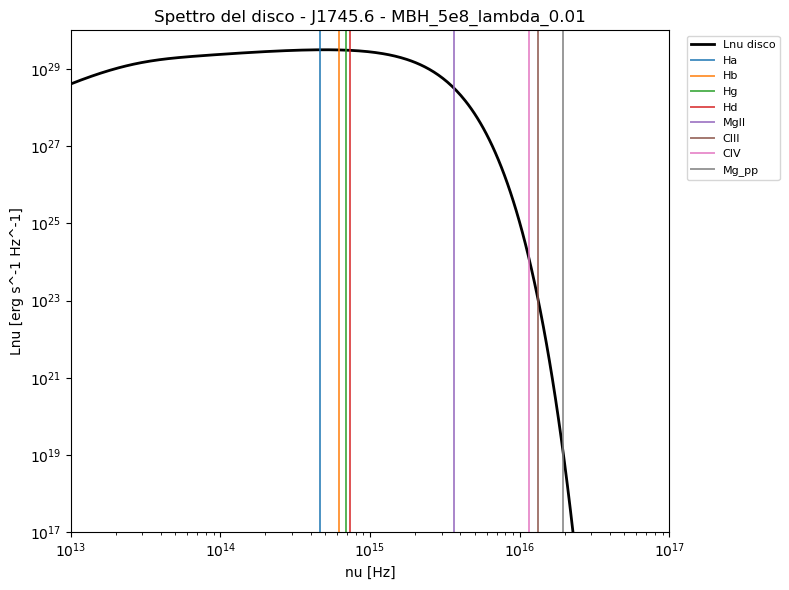

In [11]:
# Test di un singolo blazar in un singolo scenario
scenario_test = SCENARI[0]  # scelgo il primo scenario per il test, ovvero MBH=5e8 Msun e lambda_edd=0.01

df_all_test = df_all.copy()
df_all_test["MBH_solar"] = scenario_test["MBH_solar"]
df_all_test["lambda_edd"] = scenario_test["lambda_edd"]
df_all_test["scenario"] = scenario_test["scenario"]

indice_blazar = 0   # cambio questo numero per scegliere il blazar
row = df_all_test.iloc[indice_blazar]

df_risultato_singolo = analizza_blazar(row, df_trans, norm_columns, mostra_grafico=True)

### 1.4 Analisi di tutti i blazar nei 4 scenari

In [12]:

# Analisi di tutti i blazar in tutti e 4 gli scenari
tutti_risultati_scenari = [] # lista per raccogliere i risultati di tutti gli scenari

for scenario in SCENARI:  # ciclo sugli scenari
    print(f"SCENARIO: {scenario['scenario']}")
    df_all_scenario = df_all.copy()   #creo una copia del dataframe (df) base per questo scenario
    # aggiungo le colonne specifiche dello scenario a tutto il dataframe, in modo da poterle usare poi nella funzione analizza_blazar
    df_all_scenario["MBH_solar"] = scenario["MBH_solar"] #aggiungo la colonna MBH_solar a tutto il dataframe, con lo stesso valore per ogni riga
    df_all_scenario["lambda_edd"] = scenario["lambda_edd"] #aggiungo la colonna lambda_edd a tutto il dataframe, con lo stesso valore per ogni riga
    df_all_scenario["scenario"] = scenario["scenario"]  #aggiungo la colonna scenario a tutto il dataframe, con lo stesso valore per ogni riga
    risultati_scenario = []  # lista per raccogliere i risultati di questo scenario 

    for i in range(len(df_all_scenario)): # ciclo su tutti i blazar di questo scenario
        row = df_all_scenario.iloc[i] # prendo la riga del blazar i-esimo
        df_conf = analizza_blazar(row, df_trans, norm_columns, mostra_grafico=False) # analizzo questo blazar e ottengo il dataframe di confronto
        # aggiungo le informazioni del blazar e dello scenario al dataframe dei risultati
        df_conf["label"] = row["label"] 
        df_conf["scenario"] = scenario["scenario"]
        df_conf["MBH_solar"] = scenario["MBH_solar"]
        df_conf["lambda_edd"] = scenario["lambda_edd"]
        risultati_scenario.append(df_conf)   # aggiungo il dataframe di questo blazar alla lista dei risultati di questo scenario

    df_risultati_scenario = pd.concat(risultati_scenario, ignore_index=True) # creo un unico dataframe con i risultati di tutti i blazar di questo scenario
    tutti_risultati_scenari.append(df_risultati_scenario) # aggiungo il dataframe di questo scenario alla lista dei risultati di tutti gli scenari

#STAMPO TUTTI RISULTATI IN QUESTO ORDINE: per ogni scenario seguo ordine dei blazar che ho in Tab_completa_revisione.csv 



SCENARIO: MBH_5e8_lambda_0.01
Scenario = MBH_5e8_lambda_0.01
Blazar: J1745.6
redshift = 0.078
MBH = 5.000e+08 Msun
lambda_edd = 0.010
Ledd  = 6.500e+46 erg/s
Ldisk = 6.500e+44 erg/s
Mdot  = 8.714e+24 g/s

Linee osservate del blazar:


,line_name,norm_value,L_line
0,Ha,3.631777,3.631777e+42
1,Hb,1.103068,1.103068e+42



Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,Ha,3.631777e+42,5.287321e+44,0.006869
1,Hb,1.103068e+42,4.781810e+44,0.002307


Scenario = MBH_5e8_lambda_0.01
Blazar: J0021.6-6835
redshift = 0.354
MBH = 5.000e+08 Msun
lambda_edd = 0.010
Ledd  = 6.500e+46 erg/s
Ldisk = 6.500e+44 erg/s
Mdot  = 8.714e+24 g/s

Linee osservate del blazar:


...

,line_name,L_line,L_ion,covering_factor
0,MgII,7.153948e+43,1.978104e+45,0.036166
1,Hd,1.829014e+43,1.032592e+46,0.001771


Scenario = MBH_1e9_lambda_0.1
Blazar: J170108.89
redshift = 1.895
MBH = 1.000e+09 Msun
lambda_edd = 0.100
Ledd  = 1.300e+47 erg/s
Ldisk = 1.300e+46 erg/s
Mdot  = 1.743e+26 g/s

Linee osservate del blazar:


,line_name,norm_value,L_line
0,MgII,0.211584,2.115836e+41
1,CIV,0.098785,9.878503e+40
2,CIII,0.486314,4.863144e+41



Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,MgII,2.115836e+41,1.978104e+45,0.000107
1,CIV,9.878503e+40,2.958780e+42,0.033387
2,CIII,4.863144e+41,6.142773e+41,0.791685


### 1.5 Tabelle finali dei C_f

In [13]:
# Creo un unico dataframe con i risultati di tutti i 4 scenari
df_risultati_finali = pd.concat(tutti_risultati_scenari, ignore_index=True) 

In [14]:
# 1) TABELLE PER BLAZAR
# Per ogni blazar costruisco una tabella con i 4 scenari sulle righe e le linee nelle colonne
tabelle_per_blazar = {} # dizionario per raccogliere le tabelle per ogni blazar (chiave = nome blazar, valore = tabella)
blazar_unici = sorted(df_risultati_finali["label"].unique())  # lista dei blazar, ordinati alfabeticamente

for blazar in blazar_unici:  # ciclo su ogni blazar 
    df_blazar = df_risultati_finali[df_risultati_finali["label"] == blazar].copy() # creo un dataframe con tutti i risultati di questo blazar
    tabella_blazar = df_blazar.pivot( # creo la tabella per questo blazar che contiene i 4 scenari sulle righe e le linee nelle colonne, con i valori del covering factor
        index="scenario",
        columns="line_name",
        values="covering_factor")
    #tabella_blazar = tabella_blazar.reindex(sorted(tabella_blazar.columns), axis=1) # ordino le colonne in ordine alfabetico
    #tabella_blazar = tabella_blazar.reset_index() # resetto l'indice per avere la colonna "scenario" come colonna normale
    #tabella_blazar = tabella_blazar.fillna("-") # sostituisco i valori NaN con "-" per indicare che non è possibile calcolare il covering factor (perché L_ion è zero o negativo)
    #tabelle_per_blazar[blazar] = tabella_blazar # aggiungo la tabella di questo blazar al dizionario delle tabelle per blazar
    tabella_blazar = tabella_blazar.reindex(sorted(tabella_blazar.columns), axis=1)  # ordino le colonne delle linee in ordine alfabetico
    tabella_blazar = tabella_blazar.reset_index()  # riporto "scenario" da indice a colonna normale 
    ordine_scenari = [s["scenario"] for s in SCENARI]  # uso l'ordine fisico definito all'inizio
    tabella_blazar = tabella_blazar.set_index("scenario").loc[ordine_scenari].reset_index()
    tabella_blazar = tabella_blazar.fillna("-")  # sostituisco i NaN con "-"
    tabelle_per_blazar[blazar] = tabella_blazar  # salvo la tabella nel dizionario

print(f"Tabelle create per blazar: {len(tabelle_per_blazar)}") # dovrebbe essere uguale al numero di blazar (13)
# Visualizzazione delle 13 tabelle 
for blazar, tabella in tabelle_per_blazar.items(): # ciclo su ogni blazar e tabella corrispondente
    print("\n" + "=" * 100) 
    print(f"Blazar: {blazar}")
    display(tabella) 

# Salvataggio di tutte le tabelle in un unico file CSV
with open("Cf_tabelle_blazar.csv", "w") as f:
    for blazar, tabella in tabelle_per_blazar.items():
        f.write("=" * 80 + "\n")
        f.write(f"Blazar: {blazar}\n")
        f.write("=" * 80 + "\n")
        tabella.to_csv(f, index=False)
        f.write("\n\n")

Tabelle create per blazar: 13

Blazar: J0021.6-6835


line_name,scenario,Hb,Hd,Hg
0,MBH_5e8_lambda_0.01,0.013738,0.003057,0.004108
1,MBH_5e8_lambda_0.1,0.001166,0.000248,0.000340
2,MBH_1e9_lambda_0.01,0.007432,0.001690,0.002251
3,MBH_1e9_lambda_0.1,0.000605,0.000130,0.000177



Blazar: J0050.0-4458


line_name,scenario,Ha,Hb,Hd,Hg
0,MBH_5e8_lambda_0.01,0.000631,0.000140,2.286435e-05,0.000121
1,MBH_5e8_lambda_0.1,0.000056,0.000012,1.856134e-06,0.000010
2,MBH_1e9_lambda_0.01,0.000333,0.000076,1.263839e-05,0.000066
3,MBH_1e9_lambda_0.1,0.000029,0.000006,9.729825e-07,0.000005



Blazar: J0059.1-5701


...

line_name,scenario,Ha,Hb
0,MBH_5e8_lambda_0.01,0.006869,0.002307
1,MBH_5e8_lambda_0.1,0.000615,0.000196
2,MBH_1e9_lambda_0.01,0.003622,0.001248
3,MBH_1e9_lambda_0.1,0.000315,0.000102



Blazar: J1816.9-4944


line_name,scenario,CIII,CIV,MgII
0,MBH_5e8_lambda_0.01,2.196560e+06,1.054538e+05,0.175092
1,MBH_5e8_lambda_0.1,6.126595e+01,9.700866e+00,0.003194
2,MBH_1e9_lambda_0.01,4.366994e+07,1.245472e+06,0.197138
3,MBH_1e9_lambda_0.1,2.108012e+02,2.503617e+01,0.002348



Blazar: J2237.5-8326


line_name,scenario,Hb,Hd,Hg
0,MBH_5e8_lambda_0.01,0.015212,0.000258,0.005426
1,MBH_5e8_lambda_0.1,0.001291,0.000021,0.000449
2,MBH_1e9_lambda_0.01,0.008229,0.000143,0.002973
3,MBH_1e9_lambda_0.1,0.000670,0.000011,0.000234


In [15]:
# 2) TABELLE PER SCENARIO
# Per ogni scenario costruisco una tabella con i 13 blazar sulle righe e le linee nelle colonne
tabelle_per_scenario = {}
scenari_unici = [s["scenario"] for s in SCENARI]

for scenario in scenari_unici:
    df_scenario = df_risultati_finali[df_risultati_finali["scenario"] == scenario].copy()
    tabella_scenario = df_scenario.pivot(
        index="label",
        columns="line_name",
        values="covering_factor")
    # ordino le colonne (linee)
    tabella_scenario = tabella_scenario.reindex(sorted(tabella_scenario.columns), axis=1)
    tabella_scenario = tabella_scenario.reset_index()
    tabella_scenario = tabella_scenario.fillna("-")
    tabelle_per_scenario[scenario] = tabella_scenario

# Visualizzazione delle 4 tabelle (nell'ordine giusto)
for scenario in scenari_unici:
    print("\n" + "=" * 100)
    print(f"Scenario: {scenario}")
    display(tabelle_per_scenario[scenario])


Scenario: MBH_5e8_lambda_0.01


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.013738,0.003057,0.004108,-
1,J0050.0-4458,-,-,0.000631,0.00014,0.000023,0.000121,-
2,J0059.1-5701,-,-,-,-,0.043824,0.094628,2.002049
3,J0133.2-5159,-,-,-,-,0.041624,-,2.696624
4,J0508.2-1936,1193411.124051,594212.001571,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.044809,0.064434,0.024008,7.499409
6,J1123.3-2529,-,-,0.004104,0.00882,0.001304,0.003724,-
7,J1329.4-0530,-,-,-,-,0.094669,0.026786,2.058971
8,J152422.56,1181.124332,-,-,-,0.000503,-,0.005954
9,J170108.89,8249.406622,140.628256,-,-,-,-,0.007975



Scenario: MBH_5e8_lambda_0.1


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.001166,0.000248,0.00034,-
1,J0050.0-4458,-,-,0.000056,0.000012,0.000002,0.00001,-
2,J0059.1-5701,-,-,-,-,0.003558,0.007822,0.03652
3,J0133.2-5159,-,-,-,-,0.003379,-,0.04919
4,J0508.2-1936,33.286344,54.662549,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.003804,0.005231,0.001984,0.136799
6,J1123.3-2529,-,-,0.000367,0.000749,0.000106,0.000308,-
7,J1329.4-0530,-,-,-,-,0.007685,0.002214,0.037558
8,J152422.56,0.032944,-,-,-,0.000041,-,0.000109
9,J170108.89,0.230091,0.012937,-,-,-,-,0.000145



Scenario: MBH_1e9_lambda_0.01


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.007432,0.00169,0.002251,-
1,J0050.0-4458,-,-,0.000333,0.000076,0.000013,0.000066,-
2,J0059.1-5701,-,-,-,-,0.024224,0.051852,2.254128
3,J0133.2-5159,-,-,-,-,0.023008,-,3.036157
4,J0508.2-1936,23726274.526622,7017997.100168,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.024239,0.035616,0.013156,8.443663
6,J1123.3-2529,-,-,0.002164,0.004771,0.000721,0.002041,-
7,J1329.4-0530,-,-,-,-,0.052329,0.014678,2.318217
8,J152422.56,23482.000119,-,-,-,0.000278,-,0.006704
9,J170108.89,164006.922895,1660.903332,-,-,-,-,0.00898



Scenario: MBH_1e9_lambda_0.1


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.000605,0.00013,0.000177,-
1,J0050.0-4458,-,-,0.000029,0.000006,0.000001,0.000005,-
2,J0059.1-5701,-,-,-,-,0.001865,0.004083,0.02685
3,J0133.2-5159,-,-,-,-,0.001771,-,0.036166
4,J0508.2-1936,114.5302,141.074081,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.001974,0.002742,0.001036,0.100578
6,J1123.3-2529,-,-,0.000188,0.000389,0.000055,0.000161,-
7,J1329.4-0530,-,-,-,-,0.004029,0.001156,0.027614
8,J152422.56,0.113351,-,-,-,0.000021,-,0.00008
9,J170108.89,0.791685,0.033387,-,-,-,-,0.000107


### Grafico dei covering factor in funzione delle due lambda_edd e delle due masse(colori); lo ripeto per ogni riga di emissione e per ogni blazar

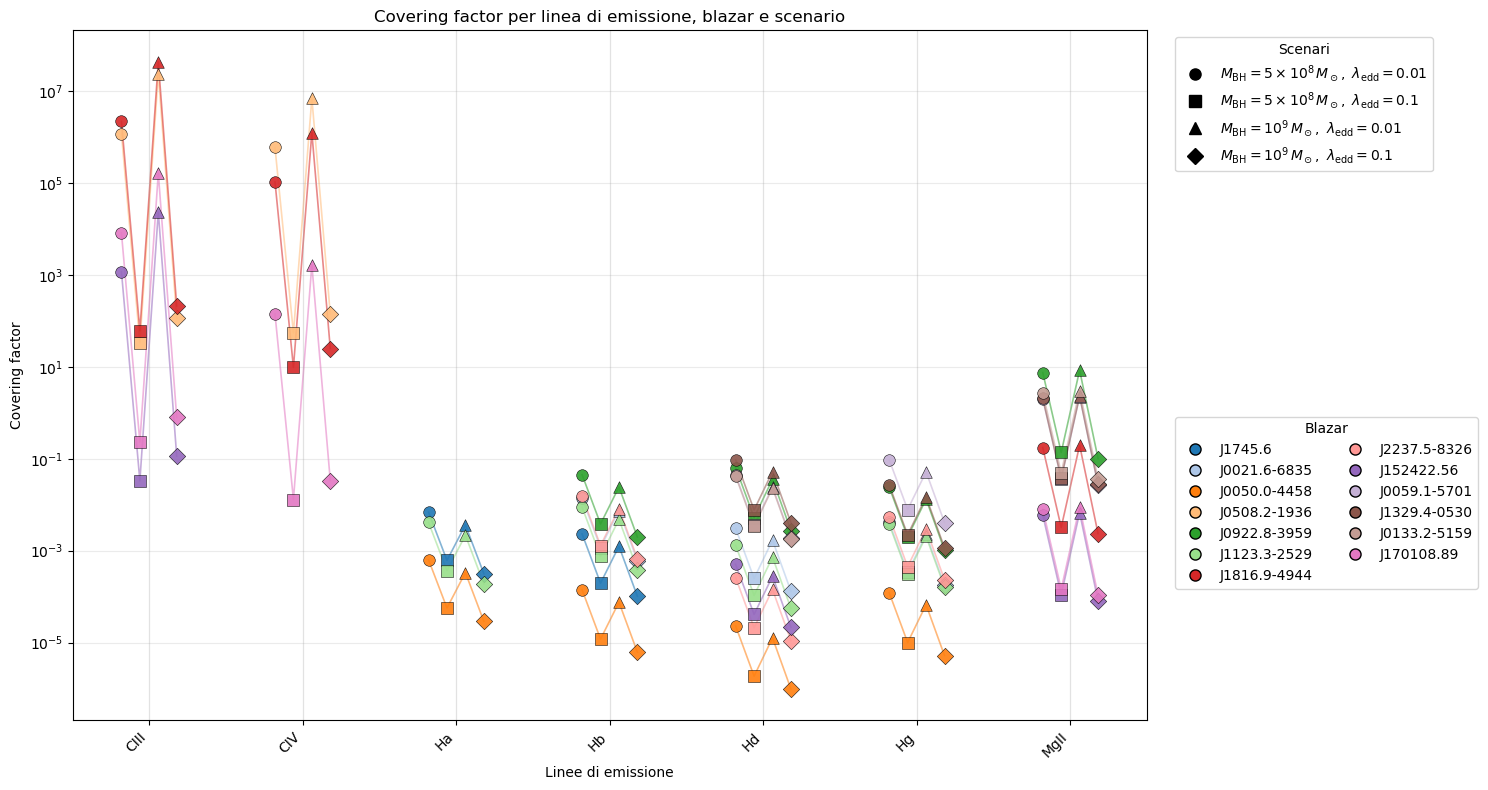

In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1. Preparo i dati
# =========================
df_plot = df_risultati_finali.copy()

# Tengo solo valori validi e positivi
df_plot = df_plot[df_plot["covering_factor"].notna()].copy()
df_plot = df_plot[df_plot["covering_factor"] > 0].copy()

# Ordine fisico delle linee, se presenti
ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_plot["line_name"].dropna().unique().tolist()
linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]

# Se ci fossero altre linee non incluse sopra, le aggiungo in fondo
altre_linee = [l for l in sorted(linee_presenti) if l not in linee_uniche]
linee_uniche = linee_uniche + altre_linee

# Ordine dei blazar: uso quello originale del file input
ordine_blazar = df_all["label"].tolist()

# Coordinate x base per le linee
x_map = {linea: i for i, linea in enumerate(linee_uniche)}
df_plot["x_base"] = df_plot["line_name"].map(x_map)

# =========================
# 2. Ordine e offset dei 4 scenari
# =========================
ordine_scenari = [
    "MBH_5e8_lambda_0.01",
    "MBH_5e8_lambda_0.1",
    "MBH_1e9_lambda_0.01",
    "MBH_1e9_lambda_0.1",
]

offset_scenario = {
    "MBH_5e8_lambda_0.01": -0.18,
    "MBH_5e8_lambda_0.1":  -0.06,
    "MBH_1e9_lambda_0.01":  0.06,
    "MBH_1e9_lambda_0.1":   0.18,
}

df_plot["offset_scenario"] = df_plot["scenario"].map(offset_scenario)
df_plot["x"] = df_plot["x_base"] + df_plot["offset_scenario"]

# =========================
# 3. Colori per i 13 blazar
# =========================
# tab20 dà abbastanza colori distinti per 13 oggetti
cmap = plt.get_cmap("tab20")
color_map = {blazar: cmap(i) for i, blazar in enumerate(ordine_blazar)}

# =========================
# 4. Marker per i 4 scenari
# =========================
marker_map = {
    "MBH_5e8_lambda_0.01": "o",
    "MBH_5e8_lambda_0.1":  "s",
    "MBH_1e9_lambda_0.01": "^",
    "MBH_1e9_lambda_0.1":  "D",
}

# =========================
# 5. Plot
# =========================
fig, ax = plt.subplots(figsize=(15, 8))

for blazar in ordine_blazar:
    df_bl = df_plot[df_plot["label"] == blazar].copy()

    if len(df_bl) == 0:
        continue

    # ---- spezzate: per ogni linea collego i 4 scenari disponibili
    for linea in linee_uniche:
        grp_linea = df_bl[df_bl["line_name"] == linea].copy()

        if len(grp_linea) < 2:
            continue

        grp_linea["scenario"] = pd.Categorical(
            grp_linea["scenario"],
            categories=ordine_scenari,
            ordered=True
        )
        grp_linea = grp_linea.sort_values("scenario")

        ax.plot(
            grp_linea["x"],
            grp_linea["covering_factor"],
            color=color_map[blazar],
            linewidth=1.2,
            alpha=0.55,
            zorder=1
        )

    # ---- punti: uno per ogni scenario
    for scenario in ordine_scenari:
        grp = df_bl[df_bl["scenario"] == scenario].copy()

        if len(grp) == 0:
            continue

        ax.scatter(
            grp["x"],
            grp["covering_factor"],
            color=color_map[blazar],
            marker=marker_map[scenario],
            s=70,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.4,
            zorder=2
        )

# =========================
# 6. Assi e stile
# =========================
ax.set_xticks(range(len(linee_uniche)))
ax.set_xticklabels(linee_uniche, rotation=45, ha="right")
ax.set_yscale("log")
ax.set_xlabel("Linee di emissione")
ax.set_ylabel("Covering factor")
ax.set_title("Covering factor per linea di emissione, blazar e scenario")
ax.grid(True, which="both", alpha=0.25)

# linee verticali leggere per separare le linee
for i in range(len(linee_uniche)):
    ax.axvline(i, color="gray", alpha=0.08, lw=1)

# =========================
# 7. Legenda scenari (marker)
# =========================
legend_scenari = [
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=8, label=r"$M_{\rm BH}=5\times10^8\,M_\odot,\ \lambda_{\rm edd}=0.01$"),
    Line2D([0], [0], marker='s', color='black', linestyle='None',
           markersize=8, label=r"$M_{\rm BH}=5\times10^8\,M_\odot,\ \lambda_{\rm edd}=0.1$"),
    Line2D([0], [0], marker='^', color='black', linestyle='None',
           markersize=8, label=r"$M_{\rm BH}=10^9\,M_\odot,\ \lambda_{\rm edd}=0.01$"),
    Line2D([0], [0], marker='D', color='black', linestyle='None',
           markersize=8, label=r"$M_{\rm BH}=10^9\,M_\odot,\ \lambda_{\rm edd}=0.1$"),
]

leg1 = ax.legend(
    handles=legend_scenari,
    title="Scenari",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True
)

# =========================
# 8. Legenda blazar (colori)
# =========================
legend_blazar = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color_map[blazar],
           markeredgecolor='black',
           markersize=8,
           label=blazar)
    for blazar in ordine_blazar
]

leg2 = ax.legend(
    handles=legend_blazar,
    title="Blazar",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.45),
    frameon=True,
    ncol=2
)

ax.add_artist(leg1)

plt.tight_layout()
plt.show()

### Legame tra il covering factor e il redshift dei blazar nel primo scenario per le diverse righe di emissione

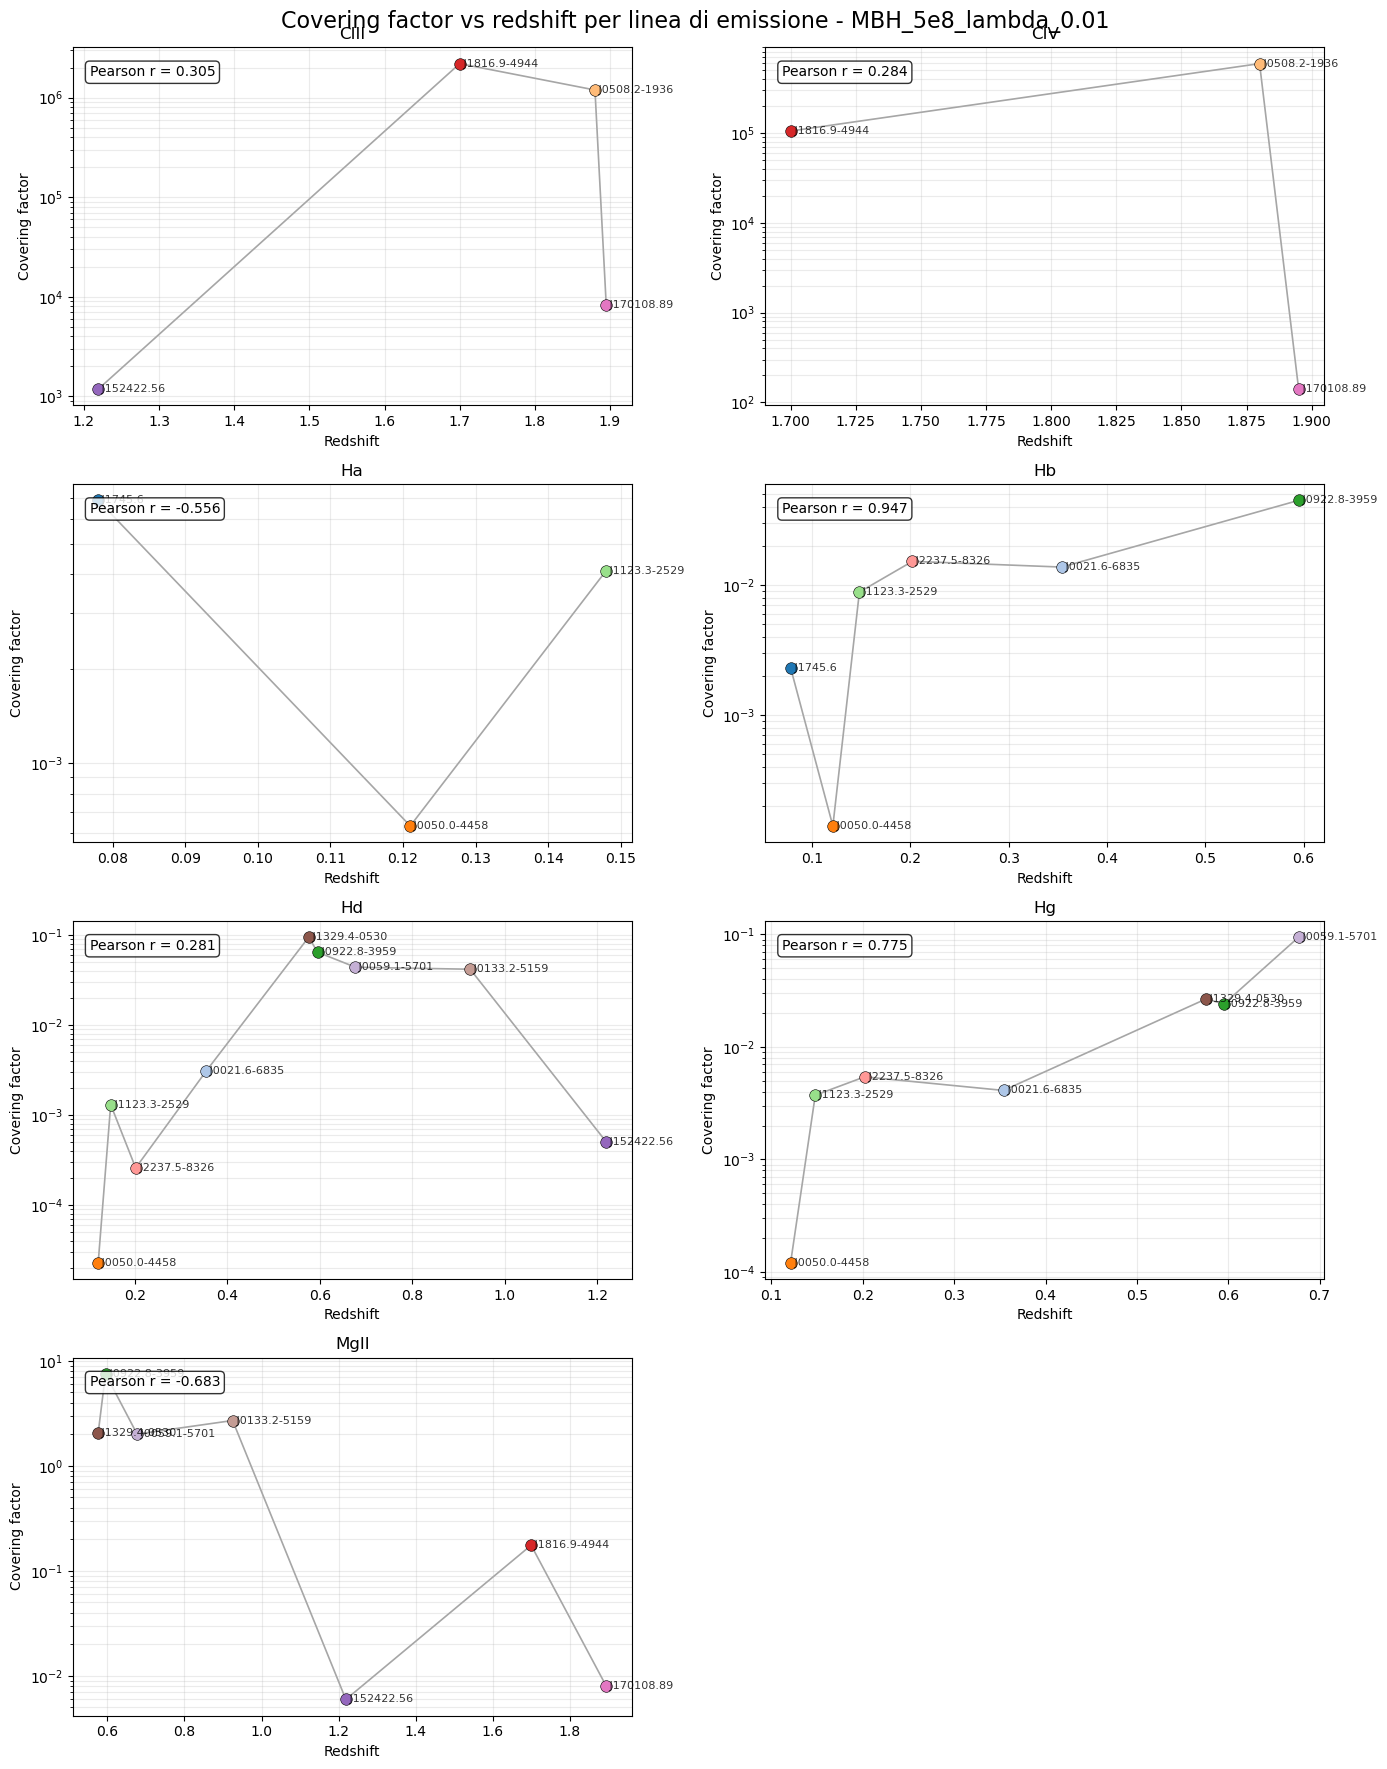

In [17]:
# Covering factor vs redshift per un solo scenario
# - un pannello per ogni linea di emissione
# - x = redshift
# - y = covering factor
# - i punti dei blazar sono collegati da una spezzata

# =========================
# 1. Scelgo lo scenario
# =========================
scenario_scelto = "MBH_5e8_lambda_0.01"   # <-- cambia qui se vuoi un altro scenario

# =========================
# 2. Aggiungo il redshift ai risultati finali
# =========================
col_redshift = trova_colonna(
    df_all,
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

df_cf_z = df_risultati_finali.merge(
    df_all[["label", col_redshift]].rename(columns={col_redshift: "redshift"}),
    on="label",
    how="left"
)

df_cf_z["redshift"] = pd.to_numeric(df_cf_z["redshift"], errors="coerce")
df_cf_z["covering_factor"] = pd.to_numeric(df_cf_z["covering_factor"], errors="coerce")

# tengo solo lo scenario scelto e valori validi
df_cf_z = df_cf_z[
    (df_cf_z["scenario"] == scenario_scelto) &
    (df_cf_z["redshift"].notna()) &
    (df_cf_z["covering_factor"].notna()) &
    (df_cf_z["covering_factor"] > 0)
].copy()

# =========================
# 3. Ordine linee
# =========================
ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_cf_z["line_name"].dropna().unique().tolist()

linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
altre_linee = [l for l in sorted(linee_presenti) if l not in linee_uniche]
linee_uniche = linee_uniche + altre_linee

# =========================
# 4. Colori per i blazar
# =========================
ordine_blazar = df_all["label"].tolist()
cmap = plt.get_cmap("tab20")
color_map_blazar = {blazar: cmap(i) for i, blazar in enumerate(ordine_blazar)}

# =========================
# 5. Layout pannelli
# =========================
n_linee = len(linee_uniche)
ncols = 2
nrows = int(np.ceil(n_linee / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, linea in zip(axes, linee_uniche):
    df_linea = df_cf_z[df_cf_z["line_name"] == linea].copy()

    if len(df_linea) == 0:
        ax.axis("off")
        continue

    # ordino per redshift così la spezzata ha senso
    df_linea = df_linea.sort_values("redshift")

    # spezzata che collega i blazar
    ax.plot(
        df_linea["redshift"],
        df_linea["covering_factor"],
        color="gray",
        linewidth=1.2,
        alpha=0.7,
        zorder=1
    )

    # punti colorati per blazar
    for _, row in df_linea.iterrows():
        ax.scatter(
            row["redshift"],
            row["covering_factor"],
            color=color_map_blazar[row["label"]],
            s=70,
            edgecolors="black",
            linewidths=0.4,
            zorder=2
        )

        # etichetta facoltativa accanto al punto
        ax.text(
            row["redshift"],
            row["covering_factor"],
            f" {row['label']}",
            fontsize=8,
            va="center",
            ha="left",
            alpha=0.8
        )

    # Pearson per questa linea
    if len(df_linea) >= 2 and df_linea["redshift"].nunique() > 1 and df_linea["covering_factor"].nunique() > 1:
        pearson = df_linea["redshift"].corr(df_linea["covering_factor"], method="pearson")
    else:
        pearson = np.nan

    ax.text(
        0.03, 0.95,
        f"Pearson r = {pearson:.3f}" if pd.notna(pearson) else "Pearson r = nan",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    ax.set_title(linea)
    ax.set_xlabel("Redshift")
    ax.set_ylabel("Covering factor")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)

# spengo eventuali pannelli vuoti
for j in range(len(linee_uniche), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Covering factor vs redshift per linea di emissione - {scenario_scelto}", fontsize=16)
plt.tight_layout()
plt.show()

Media dei covering factor per blazar - scenario MBH_5e8_lambda_0.01


,label,Cf_mean,Cf_std,N_linee,redshift
0,J1745.6,0.004588,3.225851e-03,2,0.078
1,J0050.0-4458,0.000229,2.729795e-04,4,0.121
2,J1123.3-2529,0.004488,3.143112e-03,4,0.148
3,J2237.5-8326,0.006965,7.594610e-03,3,0.202
4,J0021.6-6835,0.006968,5.886804e-03,3,0.354
5,J1329.4-0530,0.726809,1.154185e+00,3,0.576
6,J0922.8-3959,1.908165,3.727533e+00,4,0.595
7,J0059.1-5701,0.713500,1.116205e+00,3,0.677
8,J0133.2-5159,1.369124,1.877369e+00,2,0.925
9,J152422.56,393.710263,6.819206e+02,3,1.219


Pearson(<Cf>, z) per MBH_5e8_lambda_0.01 = 0.6580


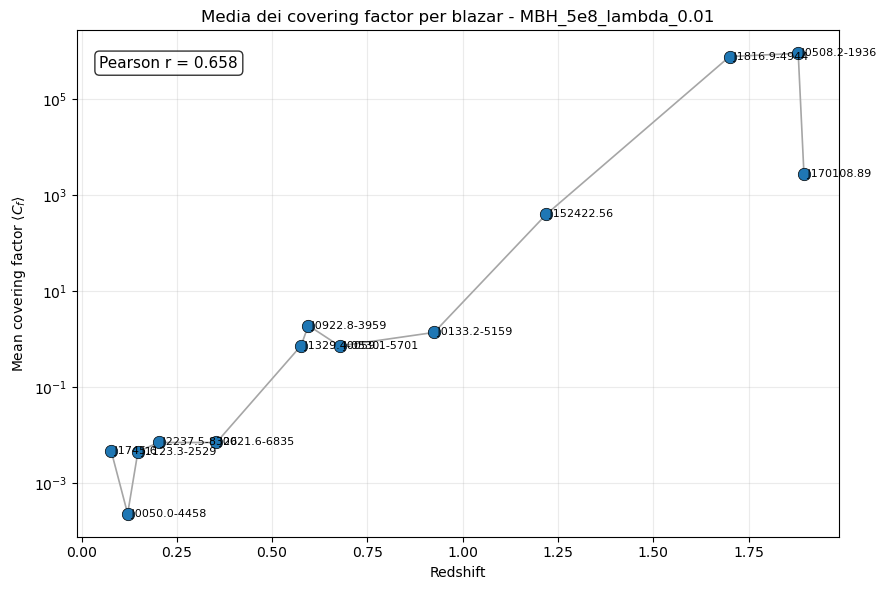

In [18]:
# Media dei covering factor per blazar nel primo scenario
# Per ogni blazar faccio la media dei covering factor delle diverse linee osservate
# e poi plotto <Cf> vs redshift

# =========================
# 1. Scelgo il primo scenario
# =========================
scenario_scelto = SCENARI[0]["scenario"]   # primo scenario: MBH_5e8_lambda_0.01

# =========================
# 2. Recupero il redshift dal dataframe originale
# =========================
col_redshift = trova_colonna(
    df_all,
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

# =========================
# 3. Tengo solo il primo scenario e valori validi
# =========================
df_cf_mean = df_risultati_finali.copy()

df_cf_mean = df_cf_mean[df_cf_mean["scenario"] == scenario_scelto].copy()
df_cf_mean["covering_factor"] = pd.to_numeric(df_cf_mean["covering_factor"], errors="coerce")

df_cf_mean = df_cf_mean[
    df_cf_mean["covering_factor"].notna() &
    (df_cf_mean["covering_factor"] > 0)
].copy()

# =========================
# 4. Media dei covering factor per blazar
# =========================
df_cf_mean_blazar = (
    df_cf_mean
    .groupby("label", as_index=False)
    .agg(
        Cf_mean=("covering_factor", "mean"),
        Cf_std=("covering_factor", "std"),
        N_linee=("covering_factor", "count")
    )
)

# aggiungo il redshift
df_cf_mean_blazar = df_cf_mean_blazar.merge(
    df_all[["label", col_redshift]].rename(columns={col_redshift: "redshift"}),
    on="label",
    how="left"
)

df_cf_mean_blazar["redshift"] = pd.to_numeric(df_cf_mean_blazar["redshift"], errors="coerce")
df_cf_mean_blazar = df_cf_mean_blazar[df_cf_mean_blazar["redshift"].notna()].copy()

# ordino per redshift
df_cf_mean_blazar = df_cf_mean_blazar.sort_values("redshift").reset_index(drop=True)

print(f"Media dei covering factor per blazar - scenario {scenario_scelto}")
display(df_cf_mean_blazar)

# %%
# =========================
# 5. Pearson tra Cf medio e redshift
# =========================
if (
    len(df_cf_mean_blazar) >= 2 and
    df_cf_mean_blazar["redshift"].nunique() > 1 and
    df_cf_mean_blazar["Cf_mean"].nunique() > 1
):
    pearson_mean = df_cf_mean_blazar["redshift"].corr(df_cf_mean_blazar["Cf_mean"], method="pearson")
else:
    pearson_mean = np.nan

print(f"Pearson(<Cf>, z) per {scenario_scelto} = {pearson_mean:.4f}")

# %%
# =========================
# 6. Plot: <Cf> vs redshift
# =========================
fig, ax = plt.subplots(figsize=(9, 6))

# spezzata che collega i blazar ordinati in redshift
ax.plot(
    df_cf_mean_blazar["redshift"],
    df_cf_mean_blazar["Cf_mean"],
    color="gray",
    linewidth=1.2,
    alpha=0.7,
    zorder=1
)

# punti
ax.scatter(
    df_cf_mean_blazar["redshift"],
    df_cf_mean_blazar["Cf_mean"],
    s=80,
    edgecolors="black",
    linewidths=0.5,
    zorder=2
)

# etichette dei blazar
for _, row in df_cf_mean_blazar.iterrows():
    ax.text(
        row["redshift"],
        row["Cf_mean"],
        f" {row['label']}",
        fontsize=8,
        va="center",
        ha="left"
    )
"""
# barre d'errore usando la dispersione tra linee
ax.errorbar(
    df_cf_mean_blazar["redshift"],
    df_cf_mean_blazar["Cf_mean"],
    yerr=df_cf_mean_blazar["Cf_std"],
    fmt="none",
    ecolor="gray",
    elinewidth=1,
    alpha=0.5,
    capsize=3,
    zorder=0
)
"""
ax.text(
    0.03, 0.95,
    f"Pearson r = {pearson_mean:.3f}" if pd.notna(pearson_mean) else "Pearson r = nan",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax.set_xlabel("Redshift")
ax.set_ylabel(r"Mean covering factor $\langle C_f \rangle$")
ax.set_title(f"Media dei covering factor per blazar - {scenario_scelto}")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

## 2 Calcolo della Luminosità della BLR da Vanden Berk

In [19]:
BLR_WEIGHTS_VANDENBERK = {
    "CIV": 25.291,
    "CIII": 15.943,
    "MgII": 14.725,
    "Hd": 1.066,
    "Hg": 2.616,
    "Hb": 8.649,
    "Ha": 30.832}

# Totale del template completo di Vanden Berk
BLR_TOTAL_VANDENBERK = 264.197

In [20]:
# Tengo una sola volta le linee osservate per ciascun blazar
# (L_line non dipende dallo scenario, quindi elimino i duplicati)

df_lblr_linee = df_risultati_finali[["label", "line_name", "L_line"]].copy()
df_lblr_linee = df_lblr_linee.drop_duplicates()

# associo a ogni linea il peso nel template di Vanden Berk
df_lblr_linee["w_i"] = df_lblr_linee["line_name"].map(BLR_WEIGHTS_VANDENBERK)

# tengo solo le linee presenti nel template
df_lblr_linee = df_lblr_linee[df_lblr_linee["w_i"].notna()].copy()

# Per ogni singola linea stimo una luminosità totale della BLR:
# L_BLR_i = L_line * (BLR_TOTAL_VANDENBERK / w_i)
df_lblr_linee["L_BLR_i"] = (
    df_lblr_linee["L_line"] * BLR_TOTAL_VANDENBERK / df_lblr_linee["w_i"]
)

print("Tabella delle singole stime di L_BLR per linea:")
display(df_lblr_linee)

Tabella delle singole stime di L_BLR per linea:


,label,line_name,L_line,w_i,L_BLR_i
0,J1745.6,Ha,3.631777e+42,30.832,3.112042e+43
1,J1745.6,Hb,1.103068e+42,8.649,3.369490e+43
2,J0021.6-6835,Hb,6.569277e+42,8.649,2.006687e+44
3,J0021.6-6835,Hg,1.867612e+42,2.616,1.886152e+44
4,J0021.6-6835,Hd,1.343418e+42,1.066,3.329522e+44
5,J0050.0-4458,Ha,3.335316e+41,30.832,2.858006e+42
6,J0050.0-4458,Hb,6.686534e+40,8.649,2.042505e+42
7,J0050.0-4458,Hg,5.502976e+40,2.616,5.557606e+42
8,J0050.0-4458,Hd,1.004694e+40,1.066,2.490028e+42
9,J0508.2-1936,CIV,4.174072e+44,25.291,4.360355e+45


In [21]:
# Per ogni blazar faccio la media delle varie stime L_BLR_i          NON PESATA !!!!!
df_lblr_finale = (
    df_lblr_linee
    .groupby("label", as_index=False)
    .agg(       # agg = aggregate = raggruppa per blazar e calcola le statistiche richieste sul gruppo
        n_linee_BLR=("line_name", "size"),
        linee_usate=("line_name", lambda x: ", ".join(x)),
        L_BLR_mean=("L_BLR_i", "mean")  
    )
)

print("Tabella finale con L_BLR per ciascun blazar:")
display(df_lblr_finale)

Tabella finale con L_BLR per ciascun blazar:


,label,n_linee_BLR,linee_usate,L_BLR_mean
0,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44
1,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42
2,J0059.1-5701,3,"MgII, Hg, Hd",3.356903e+45
3,J0133.2-5159,2,"MgII, Hd",2.908294e+45
4,J0508.2-1936,2,"CIV, CIII",2.763102e+45
5,J0922.8-3959,4,"MgII, Hb, Hg, Hd",3.085932e+45
6,J1123.3-2529,4,"Ha, Hb, Hg, Hd",1.151137e+44
7,J1329.4-0530,3,"MgII, Hg, Hd",4.173302e+45
8,J152422.56,3,"MgII, CIII, Hd",1.959071e+43
9,J170108.89,3,"MgII, CIV, CIII",4.295690e+42


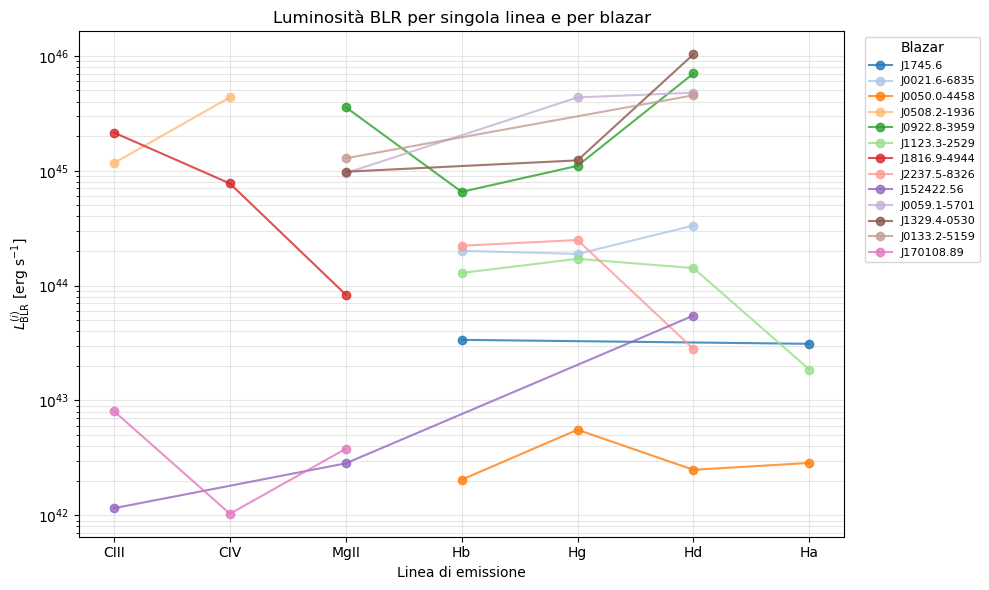

In [22]:
#L_BLR per singola linea e per ogni blazar
# - x = linee di emissione
# - y = L_BLR_i
# - colore = blazar


# =========================
# 1. Dati (già costruiti)
# =========================
df_plot = df_lblr_linee.copy()

df_plot = df_plot[
    df_plot["L_BLR_i"].notna() &
    (df_plot["L_BLR_i"] > 0)
].copy()

# =========================
# 2. Ordine linee (bello e fisico)
# =========================
ordine_linee = ["CIII", "CIV", "MgII", "Hb", "Hg", "Hd", "Ha"]

linee_presenti = df_plot["line_name"].unique().tolist()
linee_ordinate = [l for l in ordine_linee if l in linee_presenti]

# aggiungo eventuali linee extra
altre = [l for l in sorted(linee_presenti) if l not in linee_ordinate]
linee_ordinate += altre

# mapping x
x_map = {linea: i for i, linea in enumerate(linee_ordinate)}

# =========================
# 3. Setup grafico
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

blazar_list = df_plot["label"].unique().tolist()

# colori
cmap = plt.get_cmap("tab20")
color_map = {blazar: cmap(i) for i, blazar in enumerate(blazar_list)}

# =========================
# 4. Plot
# =========================
for blazar in blazar_list:
    
    df_b = df_plot[df_plot["label"] == blazar].copy()
    
    if len(df_b) == 0:
        continue
    
    df_b["x"] = df_b["line_name"].map(x_map)
    df_b = df_b.sort_values("x")
    
    ax.plot(
        df_b["x"],
        df_b["L_BLR_i"],
        marker="o",
        linewidth=1.5,
        markersize=6,
        color=color_map[blazar],
        alpha=0.8,
        label=blazar
    )

# =========================
# 5. Assi
# =========================
ax.set_xticks(range(len(linee_ordinate)))
ax.set_xticklabels(linee_ordinate)

ax.set_yscale("log")

ax.set_xlabel("Linea di emissione")
ax.set_ylabel(r"$L_{\rm BLR}^{(i)}$ [erg s$^{-1}$]")
ax.set_title("Luminosità BLR per singola linea e per blazar")

ax.grid(True, which="both", alpha=0.3)

# =========================
# 6. Legenda
# =========================
ax.legend(
    title="Blazar",
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

Tabella riassuntiva per L_BLR media:


,label,L_BLR_mean,L_BLR_std,L_BLR_median,n_linee_BLR,linee_usate
0,J0050.0-4458,3.237036e+42,1.582575e+42,2.674017e+42,4,"Ha, Hb, Hg, Hd"
1,J170108.89,4.295690e+42,3.539998e+42,3.796247e+42,3,"MgII, CIV, CIII"
2,J152422.56,1.959071e+43,3.048989e+43,2.834239e+42,3,"MgII, CIII, Hd"
3,J1745.6,3.240766e+43,1.820436e+42,3.240766e+43,2,"Ha, Hb"
4,J1123.3-2529,1.151137e+44,6.671185e+43,1.354318e+44,4,"Ha, Hb, Hg, Hd"
5,J2237.5-8326,1.664891e+44,1.206005e+44,2.221921e+44,3,"Hb, Hg, Hd"
6,J0021.6-6835,2.407453e+44,8.008055e+43,2.006687e+44,3,"Hb, Hg, Hd"
7,J1816.9-4944,1.000999e+45,1.049843e+45,7.738245e+44,3,"MgII, CIV, CIII"
8,J0508.2-1936,2.763102e+45,2.258857e+45,2.763102e+45,2,"CIV, CIII"
9,J0133.2-5159,2.908294e+45,2.297712e+45,2.908294e+45,2,"MgII, Hd"


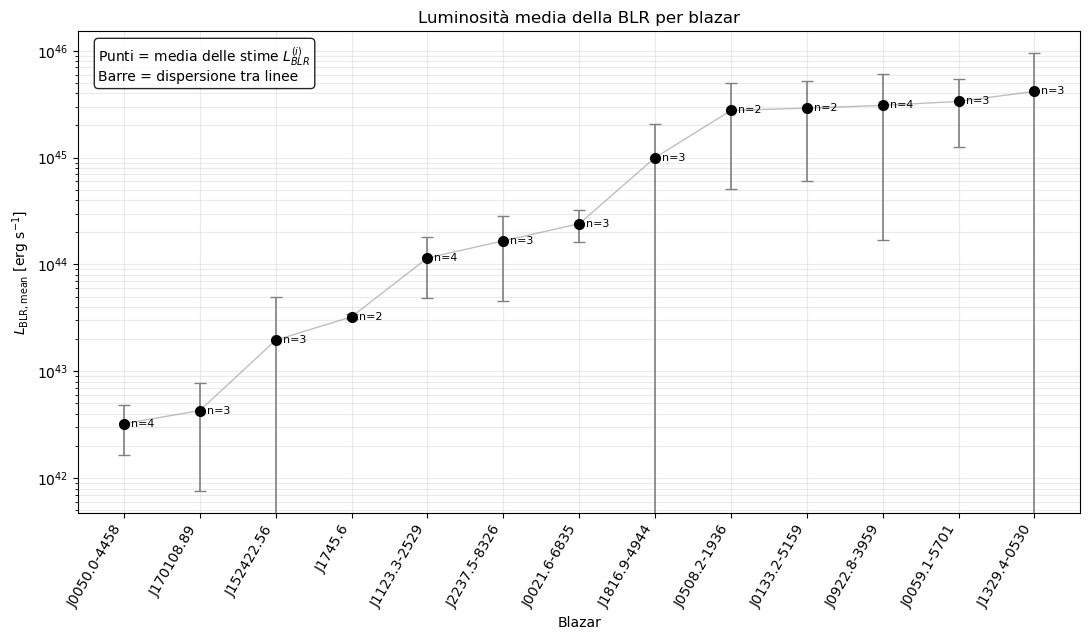

In [23]:
# %% [markdown]
# ### Grafico sensato per la L_BLR media
# - x = blazar
# - y = L_BLR_mean
# - barre d'errore = dispersione tra le stime L_BLR_i delle singole linee
# - scala logaritmica
# - blazar ordinati per L_BLR_mean

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Ricostruisco una tabella riassuntiva autonoma
# =========================
# parto dalle stime per singola linea già calcolate in df_lblr_linee
df_plot = df_lblr_linee.copy()

df_plot = df_plot[
    df_plot["L_BLR_i"].notna() &
    (df_plot["L_BLR_i"] > 0)
].copy()

# tabella riassuntiva per blazar
df_lblr_plot = (
    df_plot
    .groupby("label", as_index=False)
    .agg(
        L_BLR_mean=("L_BLR_i", "mean"),
        L_BLR_std=("L_BLR_i", "std"),
        L_BLR_median=("L_BLR_i", "median"),
        n_linee_BLR=("L_BLR_i", "count"),
        linee_usate=("line_name", lambda x: ", ".join(x))
    )
)

# se un blazar ha una sola linea, std -> NaN; la metto a 0 per il plot
df_lblr_plot["L_BLR_std"] = df_lblr_plot["L_BLR_std"].fillna(0.0)

# ordino per L_BLR_mean crescente
df_lblr_plot = df_lblr_plot.sort_values("L_BLR_mean").reset_index(drop=True)

print("Tabella riassuntiva per L_BLR media:")
display(df_lblr_plot)

# %%
# =========================
# 2. Grafico
# =========================
fig, ax = plt.subplots(figsize=(11, 6.5))

x = np.arange(len(df_lblr_plot))
y = df_lblr_plot["L_BLR_mean"].values
yerr = df_lblr_plot["L_BLR_std"].values

# punti + barre d'errore
ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.2,
    color="black",
    ecolor="gray",
    elinewidth=1.2,
    zorder=3
)

# linea leggera che collega i punti ordinati
ax.plot(
    x, y,
    color="gray",
    alpha=0.5,
    linewidth=1.0,
    zorder=2
)

# etichette con numero di linee usate
for i, row in df_lblr_plot.iterrows():
    ax.text(
        i,
        row["L_BLR_mean"],
        f"  n={int(row['n_linee_BLR'])}",
        fontsize=8,
        va="center",
        ha="left"
    )

ax.set_xticks(x)
ax.set_xticklabels(df_lblr_plot["label"], rotation=60, ha="right")

ax.set_yscale("log")
ax.set_ylabel(r"$L_{\rm BLR,mean}$ [erg s$^{-1}$]")
ax.set_xlabel("Blazar")
ax.set_title(r"Luminosità media della BLR per blazar")

ax.grid(True, which="both", alpha=0.25)

# box esplicativo
ax.text(
    0.02, 0.97,
    "Punti = media delle stime $L_{BLR}^{(i)}$\nBarre = dispersione tra linee",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.tight_layout()
plt.show()

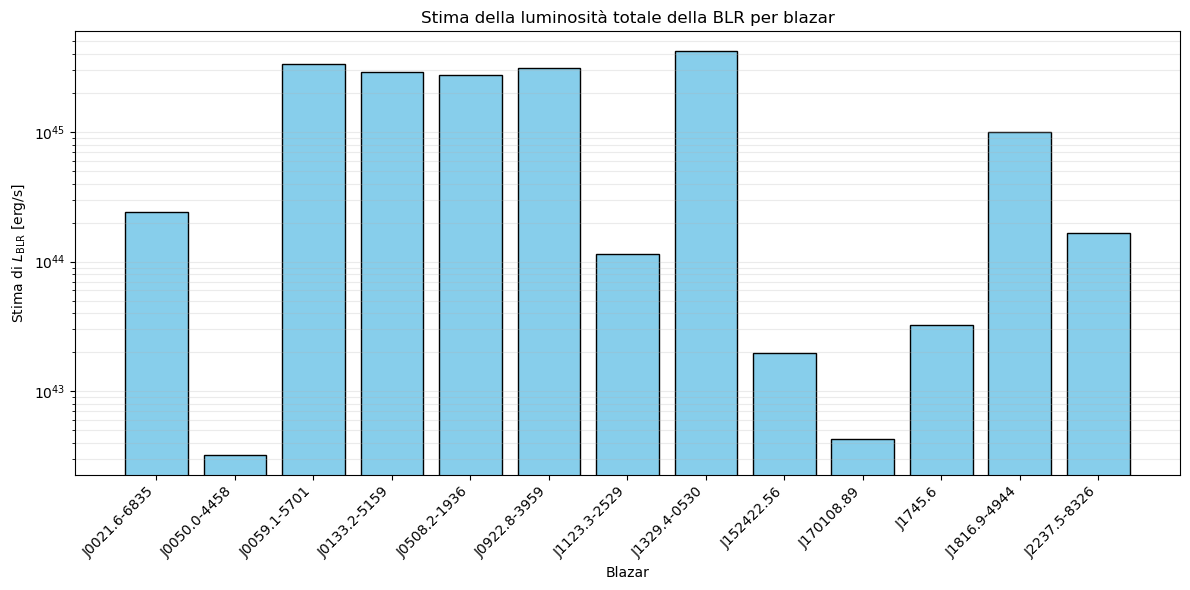

In [24]:
# grafico L_BLR sulle y e blazar sulle x
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    df_lblr_finale["label"],
    df_lblr_finale["L_BLR_mean"],
    color="skyblue",
    edgecolor="black"
)
ax.set_yscale("log")
ax.set_xlabel("Blazar")
ax.set_ylabel(r"Stima di $L_{\rm BLR}$ [erg/s]")
ax.set_title("Stima della luminosità totale della BLR per blazar")  
ax.grid(True, which="both", alpha=0.25, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Confronto tra L_BLR e L_disk

In [25]:
# Tabella degli scenari con Ledd e Ldisk

df_scenari = pd.DataFrame(SCENARI).copy()
df_scenari["Ledd"] = 1.3e38 * df_scenari["MBH_solar"]
df_scenari["Ldisk"] = df_scenari["lambda_edd"] * df_scenari["Ledd"]

print("Tabella scenari:")
display(df_scenari)

Tabella scenari:


,scenario,MBH_solar,lambda_edd,Ledd,Ldisk
0,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44
1,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45
2,MBH_1e9_lambda_0.01,1.000000e+09,0.01,1.300000e+47,1.300000e+45
3,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.300000e+47,1.300000e+46


In [26]:
# Associo a ciascun blazar i 4 scenari, mantenendo L_BLR uguale

df_lblr_ldisk = df_lblr_finale.merge(df_scenari, how="cross")

# rapporto utile per il confronto
df_lblr_ldisk["LBLR_over_Ldisk"] = df_lblr_ldisk["L_BLR_mean"] / df_lblr_ldisk["Ldisk"]

print("Tabella completa L_BLR + Ldisk:")
display(df_lblr_ldisk)

Tabella completa L_BLR + Ldisk:


,label,n_linee_BLR,linee_usate,L_BLR_mean,scenario,MBH_solar,lambda_edd,Ledd,Ldisk,LBLR_over_Ldisk
0,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44,0.370377
1,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45,0.037038
2,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_1e9_lambda_0.01,1.000000e+09,0.01,1.300000e+47,1.300000e+45,0.185189
3,J0021.6-6835,3,"Hb, Hg, Hd",2.407453e+44,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.300000e+47,1.300000e+46,0.018519
4,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44,0.004980
5,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45,0.000498
6,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_1e9_lambda_0.01,1.000000e+09,0.01,1.300000e+47,1.300000e+45,0.002490
7,J0050.0-4458,4,"Ha, Hb, Hg, Hd",3.237036e+42,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.300000e+47,1.300000e+46,0.000249
8,J0059.1-5701,3,"MgII, Hg, Hd",3.356903e+45,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.500000e+46,6.500000e+44,5.164467
9,J0059.1-5701,3,"MgII, Hg, Hd",3.356903e+45,MBH_5e8_lambda_0.1,5.000000e+08,0.10,6.500000e+46,6.500000e+45,0.516447


In [27]:
# Tabelle per blazar: L_BLR uguale, Ldisk variabile nei 4 scenari

tabelle_lblr_ldisk_per_blazar = {}

blazar_unici = sorted(df_lblr_ldisk["label"].unique())
ordine_scenari = [s["scenario"] for s in SCENARI]

for blazar in blazar_unici:
    tabella_blazar = df_lblr_ldisk[df_lblr_ldisk["label"] == blazar].copy()
    tabella_blazar = tabella_blazar.set_index("scenario").loc[ordine_scenari].reset_index()

    tabella_blazar = tabella_blazar[
        ["scenario", "L_BLR_mean", "Ldisk", "LBLR_over_Ldisk"]
    ].copy()

    tabelle_lblr_ldisk_per_blazar[blazar] = tabella_blazar

for blazar, tabella in tabelle_lblr_ldisk_per_blazar.items():
    print("\n" + "=" * 80)
    print(f"Blazar: {blazar}")
    print("=" * 80)
    display(tabella)


Blazar: J0021.6-6835


,scenario,L_BLR_mean,Ldisk,LBLR_over_Ldisk
0,MBH_5e8_lambda_0.01,2.407453e+44,6.500000e+44,0.370377
1,MBH_5e8_lambda_0.1,2.407453e+44,6.500000e+45,0.037038
2,MBH_1e9_lambda_0.01,2.407453e+44,1.300000e+45,0.185189
3,MBH_1e9_lambda_0.1,2.407453e+44,1.300000e+46,0.018519



Blazar: J0050.0-4458


,scenario,L_BLR_mean,Ldisk,LBLR_over_Ldisk
0,MBH_5e8_lambda_0.01,3.237036e+42,6.500000e+44,0.004980
1,MBH_5e8_lambda_0.1,3.237036e+42,6.500000e+45,0.000498
2,MBH_1e9_lambda_0.01,3.237036e+42,1.300000e+45,0.002490
3,MBH_1e9_lambda_0.1,3.237036e+42,1.300000e+46,0.000249



Blazar: J0059.1-5701


...

,scenario,L_BLR_mean,Ldisk,LBLR_over_Ldisk
0,MBH_5e8_lambda_0.01,3.240766e+43,6.500000e+44,0.049858
1,MBH_5e8_lambda_0.1,3.240766e+43,6.500000e+45,0.004986
2,MBH_1e9_lambda_0.01,3.240766e+43,1.300000e+45,0.024929
3,MBH_1e9_lambda_0.1,3.240766e+43,1.300000e+46,0.002493



Blazar: J1816.9-4944


,scenario,L_BLR_mean,Ldisk,LBLR_over_Ldisk
0,MBH_5e8_lambda_0.01,1.000999e+45,6.500000e+44,1.539999
1,MBH_5e8_lambda_0.1,1.000999e+45,6.500000e+45,0.154000
2,MBH_1e9_lambda_0.01,1.000999e+45,1.300000e+45,0.769999
3,MBH_1e9_lambda_0.1,1.000999e+45,1.300000e+46,0.077000



Blazar: J2237.5-8326


,scenario,L_BLR_mean,Ldisk,LBLR_over_Ldisk
0,MBH_5e8_lambda_0.01,1.664891e+44,6.500000e+44,0.256137
1,MBH_5e8_lambda_0.1,1.664891e+44,6.500000e+45,0.025614
2,MBH_1e9_lambda_0.01,1.664891e+44,1.300000e+45,0.128069
3,MBH_1e9_lambda_0.1,1.664891e+44,1.300000e+46,0.012807


In [28]:
#stampo questi risultati in un file .csv
with open("L_BLR_Ldisk_per_blazar.csv", "w") as f:
    for blazar, tabella in tabelle_lblr_ldisk_per_blazar.items():
        f.write("=" * 80 + "\n")
        f.write(f"Blazar: {blazar}\n")
        f.write("=" * 80 + "\n")
        tabella.to_csv(f, index=False)
        f.write("\n\n")

### Legame tra il covering factor e la Lblr nel primo scenario

Tabella Cf + L_BLR per linea:


,line_name,norm_value,L_line,E_ion,nu_ion,L_ion,covering_factor,label,scenario,MBH_solar,lambda_edd,L_BLR_i
0,Ha,3.631777,3.631777e+42,1.89,4.600000e+14,5.287321e+44,0.006869,J1745.6,MBH_5e8_lambda_0.01,500000000.0,0.01,3.112042e+43
1,Hb,1.103068,1.103068e+42,2.55,6.200000e+14,4.781810e+44,0.002307,J1745.6,MBH_5e8_lambda_0.01,500000000.0,0.01,3.369490e+43
2,Hb,6.569277,6.569277e+42,2.55,6.200000e+14,4.781810e+44,0.013738,J0021.6-6835,MBH_5e8_lambda_0.01,500000000.0,0.01,2.006687e+44
3,Hg,1.867612,1.867612e+42,2.86,6.910000e+14,4.546675e+44,0.004108,J0021.6-6835,MBH_5e8_lambda_0.01,500000000.0,0.01,1.886152e+44
4,Hd,1.343418,1.343418e+42,3.02,7.370000e+14,4.394148e+44,0.003057,J0021.6-6835,MBH_5e8_lambda_0.01,500000000.0,0.01,3.329522e+44


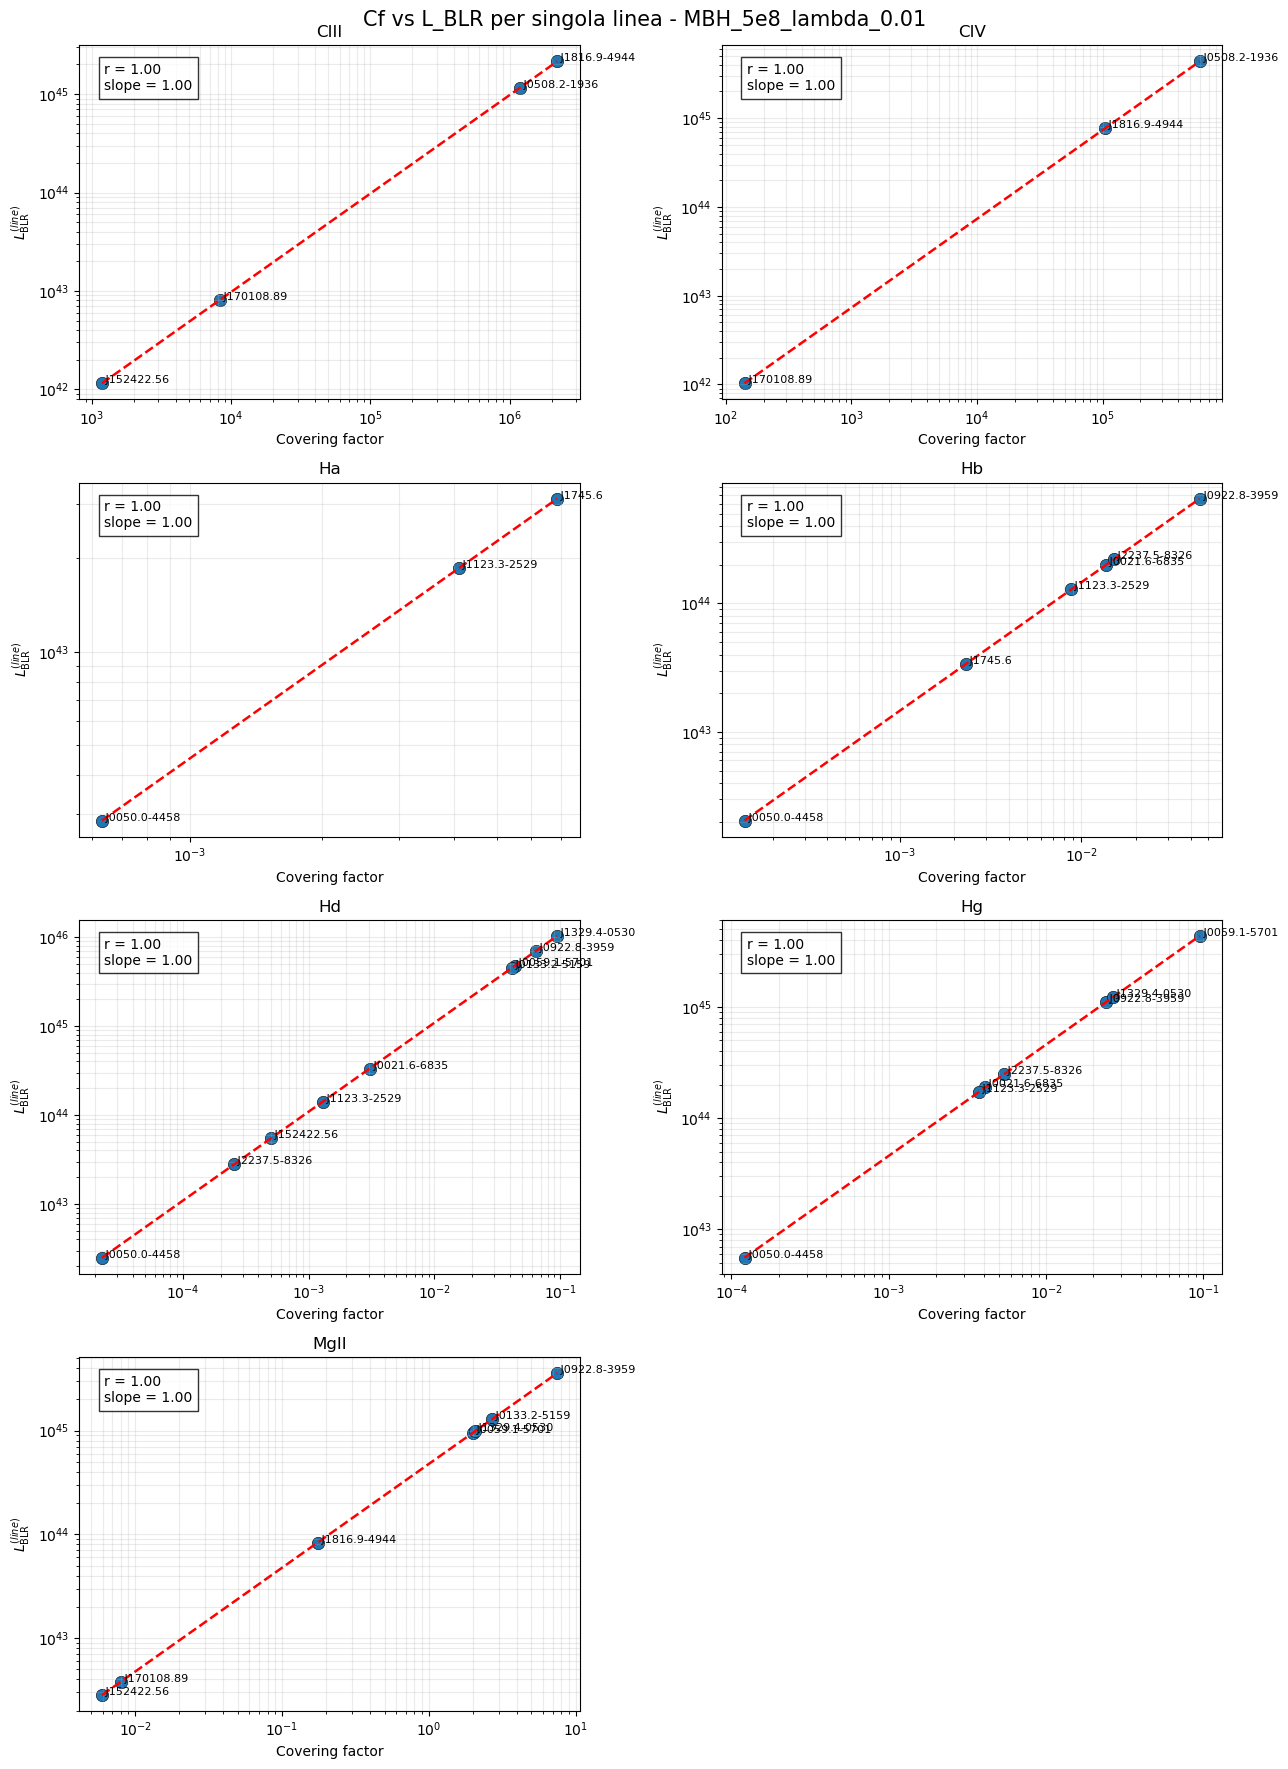

In [29]:
#  Cf vs L_BLR (per singola linea di emissione)
# - primo scenario
# - x = covering factor della linea
# - y = L_BLR stimata dalla stessa linea

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Scenario
# =========================
scenario_scelto = SCENARI[0]["scenario"]

# =========================
# 2. Dati Cf (per linea)
# =========================
df_cf = df_risultati_finali.copy()

df_cf = df_cf[
    df_cf["scenario"] == scenario_scelto
].copy()

# tengo solo valori validi
df_cf = df_cf[
    df_cf["covering_factor"].notna() &
    (df_cf["covering_factor"] > 0)
].copy()

# =========================
# 3. Dati L_BLR per linea
# =========================
# questo dataframe lo hai già creato
df_lblr_line = df_lblr_linee.copy()

# merge su label + line_name
df_line = df_cf.merge(
    df_lblr_line[["label", "line_name", "L_BLR_i"]],
    on=["label", "line_name"],
    how="inner"
)

# pulizia
df_line = df_line[
    df_line["L_BLR_i"].notna() &
    (df_line["L_BLR_i"] > 0)
].copy()

print("Tabella Cf + L_BLR per linea:")
display(df_line.head())

# %%
# =========================
# 4. Linee disponibili
# =========================
ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]

linee_presenti = df_line["line_name"].unique().tolist()
linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]

# eventuali altre linee
altre = [l for l in sorted(linee_presenti) if l not in linee_uniche]
linee_uniche = linee_uniche + altre

# %%
# =========================
# 5. Plot: un pannello per linea
# =========================
n_linee = len(linee_uniche)
ncols = 2
nrows = int(np.ceil(n_linee / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5*nrows))
axes = np.array(axes).reshape(-1)

for ax, linea in zip(axes, linee_uniche):
    
    df_l = df_line[df_line["line_name"] == linea].copy()
    
    if len(df_l) < 2:
        ax.axis("off")
        continue

    x = df_l["covering_factor"].values
    y = df_l["L_BLR_i"].values

    # scatter
    ax.scatter(
        x, y,
        s=80,
        edgecolors="black",
        linewidths=0.4
    )

    # etichette blazar
    for _, row in df_l.iterrows():
        ax.text(
            row["covering_factor"],
            row["L_BLR_i"],
            f" {row['label']}",
            fontsize=8
        )

    # =========================
    # fit log-log
    # =========================
    if np.unique(x).size > 1 and np.unique(y).size > 1:
        xlog = np.log10(x)
        ylog = np.log10(y)

        coeff = np.polyfit(xlog, ylog, 1)

        xx = np.linspace(xlog.min(), xlog.max(), 200)
        yy = coeff[0]*xx + coeff[1]

        ax.plot(
            10**xx,
            10**yy,
            color="red",
            linestyle="--",
            linewidth=1.8
        )

        slope = coeff[0]
    else:
        slope = np.nan

    # =========================
    # Pearson
    # =========================
    if len(df_l) >= 2 and np.unique(x).size > 1:
        pearson = np.corrcoef(x, y)[0,1]
    else:
        pearson = np.nan

    ax.text(
        0.05, 0.95,
        f"r = {pearson:.2f}\nslope = {slope:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(linea)
    ax.set_xlabel("Covering factor")
    ax.set_ylabel(r"$L_{\rm BLR}^{(line)}$")

    ax.grid(True, which="both", alpha=0.25)

# spegno pannelli vuoti
for j in range(len(linee_uniche), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Cf vs L_BLR per singola linea - {scenario_scelto}", fontsize=15)
plt.tight_layout()
plt.show()

Numero di righe valide per MBH_5e8_lambda_0.01: 39
Tabella con covering factor medio per blazar:


,label,Cf_mean,Cf_std,N_linee
0,J0021.6-6835,0.006968,5.886804e-03,3
1,J0050.0-4458,0.000229,2.729795e-04,4
2,J0059.1-5701,0.713500,1.116205e+00,3
3,J0133.2-5159,1.369124,1.877369e+00,2
4,J0508.2-1936,893811.562811,4.236978e+05,2
5,J0922.8-3959,1.908165,3.727533e+00,4
6,J1123.3-2529,0.004488,3.143112e-03,4
7,J1329.4-0530,0.726809,1.154185e+00,3
8,J152422.56,393.710263,6.819206e+02,3
9,J170108.89,2796.680951,4.722722e+03,3


Tabella finale Cf medio + L_BLR:


,label,Cf_mean,Cf_std,N_linee,L_BLR_mean
0,J0021.6-6835,0.006968,5.886804e-03,3,2.407453e+44
1,J0050.0-4458,0.000229,2.729795e-04,4,3.237036e+42
2,J0059.1-5701,0.713500,1.116205e+00,3,3.356903e+45
3,J0133.2-5159,1.369124,1.877369e+00,2,2.908294e+45
4,J0508.2-1936,893811.562811,4.236978e+05,2,2.763102e+45
5,J0922.8-3959,1.908165,3.727533e+00,4,3.085932e+45
6,J1123.3-2529,0.004488,3.143112e-03,4,1.151137e+44
7,J1329.4-0530,0.726809,1.154185e+00,3,4.173302e+45
8,J152422.56,393.710263,6.819206e+02,3,1.959071e+43
9,J170108.89,2796.680951,4.722722e+03,3,4.295690e+42


Pearson(<Cf>, L_BLR) = 0.1578


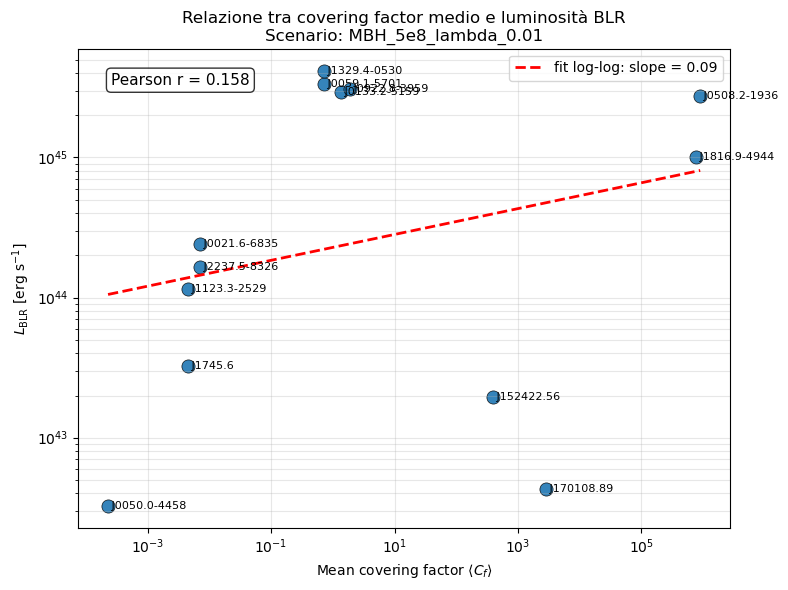

In [30]:
# Relazione tra covering factor medio e L_BLR


# =========================
# 1. Scelgo esplicitamente il primo scenario
# =========================
scenario_scelto = SCENARI[0]["scenario"]   # es. MBH_5e8_lambda_0.01

# =========================
# 2. Parto da df_risultati_finali e tengo solo il primo scenario
# =========================
df_cf = df_risultati_finali.copy()

df_cf["covering_factor"] = pd.to_numeric(df_cf["covering_factor"], errors="coerce")

df_cf = df_cf[
    (df_cf["scenario"] == scenario_scelto) &
    (df_cf["covering_factor"].notna()) &
    (df_cf["covering_factor"] > 0)
].copy()

print(f"Numero di righe valide per {scenario_scelto}: {len(df_cf)}")

# %%
# =========================
# 3. Calcolo il covering factor medio per blazar
# =========================
df_cf_mean_blazar = (
    df_cf
    .groupby("label", as_index=False)
    .agg(
        Cf_mean=("covering_factor", "mean"),
        Cf_std=("covering_factor", "std"),
        N_linee=("covering_factor", "count")
    )
)

print("Tabella con covering factor medio per blazar:")
display(df_cf_mean_blazar)

# %%
# =========================
# 4. Unisco con la tabella di L_BLR
# =========================
df_cf_lblr = df_cf_mean_blazar.merge(
    df_lblr_finale[["label", "L_BLR_mean"]],
    on="label",
    how="left"
)

df_cf_lblr["L_BLR_mean"] = pd.to_numeric(df_cf_lblr["L_BLR_mean"], errors="coerce")

df_cf_lblr = df_cf_lblr[
    df_cf_lblr["L_BLR_mean"].notna() &
    (df_cf_lblr["L_BLR_mean"] > 0)
].copy()

print("Tabella finale Cf medio + L_BLR:")
display(df_cf_lblr)

# %%
# =========================
# 5. Correlazione di Pearson
# =========================
if (
    len(df_cf_lblr) >= 2 and
    df_cf_lblr["Cf_mean"].nunique() > 1 and
    df_cf_lblr["L_BLR_mean"].nunique() > 1
):
    pearson = df_cf_lblr["Cf_mean"].corr(df_cf_lblr["L_BLR_mean"], method="pearson")
else:
    pearson = np.nan

print(f"Pearson(<Cf>, L_BLR) = {pearson:.4f}")

# %%
# =========================
# 6. Plot
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

# scatter
ax.scatter(
    df_cf_lblr["Cf_mean"],
    df_cf_lblr["L_BLR_mean"],
    s=90,
    edgecolors="black",
    linewidths=0.5,
    alpha=0.9
)

# etichette dei blazar
for _, row in df_cf_lblr.iterrows():
    ax.text(
        row["Cf_mean"],
        row["L_BLR_mean"],
        f" {row['label']}",
        fontsize=8,
        ha="left",
        va="center"
    )

# fit log-log
if (
    len(df_cf_lblr) >= 2 and
    np.all(df_cf_lblr["Cf_mean"].values > 0) and
    np.all(df_cf_lblr["L_BLR_mean"].values > 0)
):
    xlog = np.log10(df_cf_lblr["Cf_mean"].values)
    ylog = np.log10(df_cf_lblr["L_BLR_mean"].values)

    if np.unique(xlog).size > 1 and np.unique(ylog).size > 1:
        coeff = np.polyfit(xlog, ylog, 1)
        xx = np.linspace(xlog.min(), xlog.max(), 200)
        yy = coeff[0] * xx + coeff[1]

        ax.plot(
            10**xx,
            10**yy,
            color="red",
            linestyle="--",
            linewidth=2,
            label=fr"fit log-log: slope = {coeff[0]:.2f}"
        )

# box con Pearson
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson:.3f}" if pd.notna(pearson) else "Pearson r = nan",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Mean covering factor $\langle C_f \rangle$")
ax.set_ylabel(r"$L_{\rm BLR}$ [erg s$^{-1}$]")
ax.set_title(f"Relazione tra covering factor medio e luminosità BLR\nScenario: {scenario_scelto}")

ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### Legame tra il covering factor e rapporto f per il primo scenario

In [32]:

# =========================
# 1. Scelgo il primo scenario
# =========================
scenario_scelto = SCENARI[0]["scenario"]   # primo scenario

# =========================
# 2. Prendo il covering factor medio per blazar
# =========================
# uso il dataframe che hai già costruito prima:
# df_cf_mean_blazar
df_cf = df_cf_mean_blazar.copy()

# tengo solo le colonne utili e rinomino per chiarezza
df_cf = df_cf[["label", "Cf_mean", "Cf_std", "N_linee", "redshift"]].copy()

# =========================
# 3. Prendo L_BLR / L_disk per lo scenario scelto
# =========================
df_ratio = df_lblr_ldisk[
    df_lblr_ldisk["scenario"] == scenario_scelto
][["label", "scenario", "L_BLR_mean", "Ldisk", "LBLR_over_Ldisk"]].copy()

# =========================
# 4. Merge
# =========================
df_cf_ratio = df_cf.merge(
    df_ratio,
    on="label",
    how="inner"
)

# tengo solo valori validi e positivi
for col in ["Cf_mean", "LBLR_over_Ldisk", "L_BLR_mean", "Ldisk"]:
    df_cf_ratio[col] = pd.to_numeric(df_cf_ratio[col], errors="coerce")

df_cf_ratio = df_cf_ratio[
    df_cf_ratio["Cf_mean"].notna() &
    df_cf_ratio["LBLR_over_Ldisk"].notna() &
    (df_cf_ratio["Cf_mean"] > 0) &
    (df_cf_ratio["LBLR_over_Ldisk"] > 0)
].copy()

print(f"Tabella finale per il plot - scenario {scenario_scelto}")
display(df_cf_ratio)

# %%
# =========================
# 5. Correlazioni
# =========================
if (
    len(df_cf_ratio) >= 2 and
    df_cf_ratio["Cf_mean"].nunique() > 1 and
    df_cf_ratio["LBLR_over_Ldisk"].nunique() > 1
):
    pearson = df_cf_ratio["Cf_mean"].corr(df_cf_ratio["LBLR_over_Ldisk"], method="pearson")
    spearman = df_cf_ratio["Cf_mean"].corr(df_cf_ratio["LBLR_over_Ldisk"], method="spearman")
else:
    pearson = np.nan
    spearman = np.nan

print(f"Pearson(<Cf>, L_BLR/L_disk)  = {pearson:.4f}")
print(f"Spearman(<Cf>, L_BLR/L_disk) = {spearman:.4f}")

# %%
# =========================
# 6. Plot
# =========================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# punti
ax.scatter(
    df_cf_ratio["Cf_mean"],
    df_cf_ratio["LBLR_over_Ldisk"],
    s=90,
    edgecolors="black",
    linewidths=0.5,
    alpha=0.9,
    zorder=2
)

# etichette blazar
for _, row in df_cf_ratio.iterrows():
    ax.text(
        row["Cf_mean"],
        row["LBLR_over_Ldisk"],
        f" {row['label']}",
        fontsize=8,
        ha="left",
        va="center"
    )

# fit lineare in log-log
if len(df_cf_ratio) >= 2:
    xlog = np.log10(df_cf_ratio["Cf_mean"].values)
    ylog = np.log10(df_cf_ratio["LBLR_over_Ldisk"].values)

    coeff = np.polyfit(xlog, ylog, 1)
    xx = np.linspace(xlog.min(), xlog.max(), 200)
    yy = coeff[0] * xx + coeff[1]

    ax.plot(
        10**xx,
        10**yy,
        color="red",
        linestyle="--",
        linewidth=2,
        label=fr"fit log-log: slope = {coeff[0]:.2f}"
    )

# box con correlazioni
txt = (
    f"Pearson r = {pearson:.3f}\n"
    f"Spearman ρ = {spearman:.3f}\n"
    f"N = {len(df_cf_ratio)}"
)

ax.text(
    0.05, 0.95,
    txt,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Mean covering factor $\langle C_f \rangle$")
ax.set_ylabel(r"$L_{\rm BLR}/L_{\rm disk}$")
ax.set_title(f"Relazione tra $\langle C_f \\rangle$ e $L_{{\\rm BLR}}/L_{{\\rm disk}}$ - {scenario_scelto}")

ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

<>:132: SyntaxWarning: invalid escape sequence '\l'
<>:132: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13277/1045919724.py:132: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f"Relazione tra $\langle C_f \\rangle$ e $L_{{\\rm BLR}}/L_{{\\rm disk}}$ - {scenario_scelto}")


KeyError: "['redshift'] not in index"

## 3 Altri test statistici

Tabella Cf medio per blazar e scenario:


,label,scenario,MBH_solar,lambda_edd,Cf_mean,Cf_std,N_linee
0,J0021.6-6835,MBH_1e9_lambda_0.01,1.000000e+09,0.01,3.790787e-03,3.165507e-03,3
1,J0021.6-6835,MBH_1e9_lambda_0.1,1.000000e+09,0.10,3.041720e-04,2.617274e-04,3
2,J0021.6-6835,MBH_5e8_lambda_0.01,5.000000e+08,0.01,6.967662e-03,5.886804e-03,3
3,J0021.6-6835,MBH_5e8_lambda_0.1,5.000000e+08,0.10,5.846215e-04,5.056848e-04,3
4,J0050.0-4458,MBH_1e9_lambda_0.01,1.000000e+09,0.01,1.218106e-04,1.432695e-04,4
5,J0050.0-4458,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.032605e-05,1.261858e-05,4
6,J0050.0-4458,MBH_5e8_lambda_0.01,5.000000e+08,0.01,2.286360e-04,2.729795e-04,4
7,J0050.0-4458,MBH_5e8_lambda_0.1,5.000000e+08,0.10,2.004681e-05,2.466001e-05,4
8,J0059.1-5701,MBH_1e9_lambda_0.01,1.000000e+09,0.01,7.767346e-01,1.279535e+00,3
9,J0059.1-5701,MBH_1e9_lambda_0.1,1.000000e+09,0.10,1.093291e-02,1.382952e-02,3


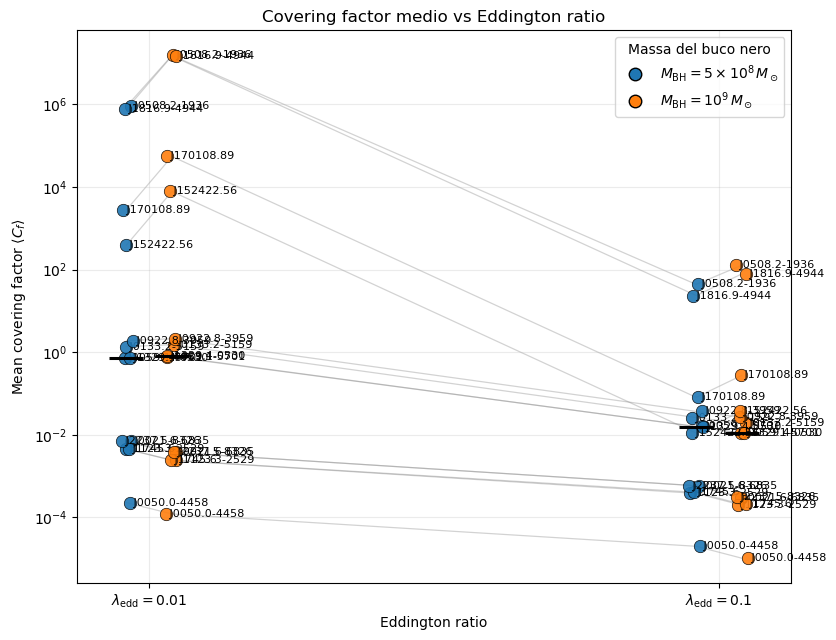

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
#  Cf vs Eddington ratio
# Uso tutti i 4 scenari:
# - x = lambda_edd
# - y = covering factor medio per blazar
# - colore = massa del buco nero

from matplotlib.lines import Line2D
# =========================
# 1. Tengo solo valori validi
# =========================
df_cf_edd = df_risultati_finali.copy()

df_cf_edd["covering_factor"] = pd.to_numeric(df_cf_edd["covering_factor"], errors="coerce")

df_cf_edd = df_cf_edd[
    df_cf_edd["covering_factor"].notna() &
    (df_cf_edd["covering_factor"] > 0)
].copy()

# =========================
# 2. Media dei covering factor per blazar e scenario
# =========================
df_cf_edd_mean = (
    df_cf_edd
    .groupby(["label", "scenario", "MBH_solar", "lambda_edd"], as_index=False)
    .agg(
        Cf_mean=("covering_factor", "mean"),
        Cf_std=("covering_factor", "std"),
        N_linee=("covering_factor", "count")
    )
)

print("Tabella Cf medio per blazar e scenario:")
display(df_cf_edd_mean)

# %%
# =========================
# 3. Plot
# =========================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# posizioni base per lambda_edd
x_map = {0.01: 0, 0.1: 1}

# piccolo offset per separare le due masse
offset_map = {
    5e8: -0.04,
    1e9: +0.04
}

# colori per massa
color_map = {
    5e8: "tab:blue",
    1e9: "tab:orange"
}

# per evitare sovrapposizioni perfette, aggiungo un jitter piccolo e riproducibile
rng = np.random.default_rng(42)

for _, row in df_cf_edd_mean.iterrows():
    x = x_map[row["lambda_edd"]] + offset_map[row["MBH_solar"]] + rng.uniform(-0.012, 0.012)
    y = row["Cf_mean"]

    ax.scatter(
        x, y,
        color=color_map[row["MBH_solar"]],
        s=80,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9,
        zorder=3
    )

    ax.text(
        x, y,
        f" {row['label']}",
        fontsize=8,
        ha="left",
        va="center"
    )

# opzionale: collego per ogni blazar i 4 scenari ordinati per lambda e massa
ordine_blazar = df_cf_edd_mean["label"].drop_duplicates().tolist()

for blazar in ordine_blazar:
    grp = df_cf_edd_mean[df_cf_edd_mean["label"] == blazar].copy()
    grp = grp.sort_values(["lambda_edd", "MBH_solar"])

    x_vals = [
        x_map[r["lambda_edd"]] + offset_map[r["MBH_solar"]]
        for _, r in grp.iterrows()
    ]
    y_vals = grp["Cf_mean"].values

    ax.plot(
        x_vals, y_vals,
        color="gray",
        alpha=0.35,
        linewidth=0.9,
        zorder=1
    )

# barre verticali riassuntive: mediana per ciascun gruppo
for mbh in [5e8, 1e9]:
    for lam in [0.01, 0.1]:
        grp = df_cf_edd_mean[
            (df_cf_edd_mean["MBH_solar"] == mbh) &
            (df_cf_edd_mean["lambda_edd"] == lam)
        ]

        if len(grp) == 0:
            continue

        x = x_map[lam] + offset_map[mbh]
        y_med = grp["Cf_mean"].median()

        ax.hlines(
            y_med,
            x - 0.03, x + 0.03,
            color="black",
            linewidth=2.2,
            zorder=4
        )

# stile assi
ax.set_xticks([0, 1])
ax.set_xticklabels([r"$\lambda_{\rm edd}=0.01$", r"$\lambda_{\rm edd}=0.1$"])
ax.set_yscale("log")
ax.set_ylabel(r"Mean covering factor $\langle C_f \rangle$")
ax.set_xlabel("Eddington ratio")
ax.set_title(r"Covering factor medio vs Eddington ratio")
ax.grid(True, which="both", alpha=0.25)

# legenda masse
legend_masse = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="tab:blue", markeredgecolor='black',
           markersize=9, label=r"$M_{\rm BH}=5\times10^8\,M_\odot$"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="tab:orange", markeredgecolor='black',
           markersize=9, label=r"$M_{\rm BH}=10^9\,M_\odot$")
]

ax.legend(handles=legend_masse, title="Massa del buco nero", loc="best")

plt.tight_layout()
plt.show()

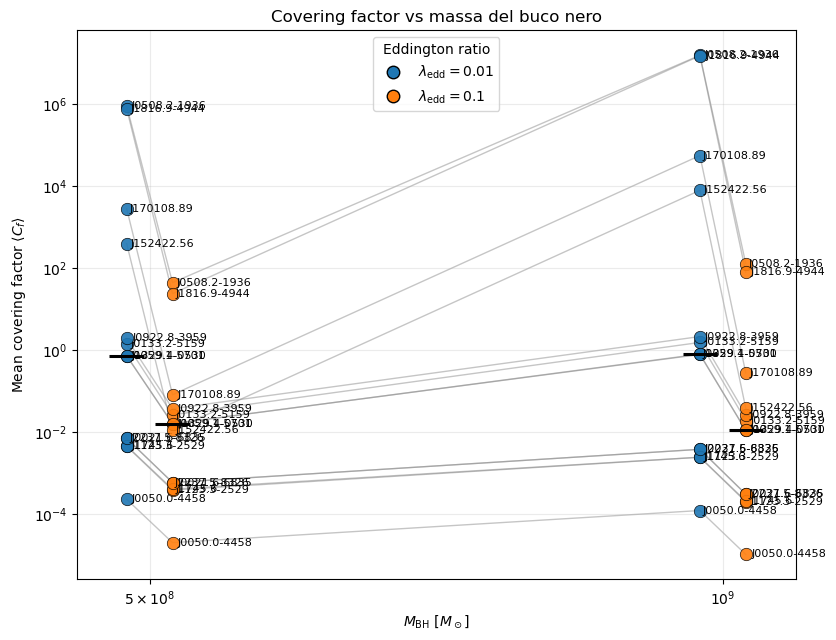

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

In [ ]:
# %% [markdown]
# ### Covering factor vs massa del buco nero
# - x = MBH
# - y = <Cf>
# - colore = lambda_edd
# - spezzata grigia che collega i 4 punti di ciascun blazar

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 1. Dati Cf medio
# =========================
df_cf_mass = df_risultati_finali.copy()

df_cf_mass["covering_factor"] = pd.to_numeric(df_cf_mass["covering_factor"], errors="coerce")

df_cf_mass = df_cf_mass[
    df_cf_mass["covering_factor"].notna() &
    (df_cf_mass["covering_factor"] > 0)
].copy()

df_cf_mass_mean = (
    df_cf_mass
    .groupby(["label", "scenario", "MBH_solar", "lambda_edd"], as_index=False)
    .agg(
        Cf_mean=("covering_factor", "mean"),
        Cf_std=("covering_factor", "std"),
        N_linee=("covering_factor", "count")
    )
)

# =========================
# 2. Setup grafico
# =========================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# posizione base delle due masse
x_map = {
    5e8: 0,
    1e9: 1
}

# piccolo offset orizzontale per separare i due lambda a massa fissata
offset_map = {
    0.01: -0.04,
    0.1:  +0.04
}

# colori dei punti per lambda_edd
color_map = {
    0.01: "tab:blue",
    0.1: "tab:orange"
}

# jitter piccolo per i testi, non per i punti
rng = np.random.default_rng(42)

# x finale
df_cf_mass_mean["x"] = df_cf_mass_mean.apply(
    lambda r: x_map[r["MBH_solar"]] + offset_map[r["lambda_edd"]],
    axis=1
)

# =========================
# 3. Spezzate grigie: unisco i 4 punti di ciascun blazar
# =========================
blazar_list = df_cf_mass_mean["label"].unique().tolist()

for blazar in blazar_list:
    grp = df_cf_mass_mean[df_cf_mass_mean["label"] == blazar].copy()

    if len(grp) < 2:
        continue

    # Ordine "a percorso":
    # (5e8,0.01) -> (5e8,0.1) -> (1e9,0.01) -> (1e9,0.1)
    grp["MBH_order"] = grp["MBH_solar"].map({5e8: 0, 1e9: 1})
    grp["lam_order"] = grp["lambda_edd"].map({0.01: 0, 0.1: 1})
    grp = grp.sort_values(["MBH_order", "lam_order"])

    ax.plot(
        grp["x"],
        grp["Cf_mean"],
        color="gray",
        alpha=0.45,
        linewidth=1.0,
        zorder=1
    )

# =========================
# 4. Punti
# =========================
for _, row in df_cf_mass_mean.iterrows():
    x = row["x"]
    y = row["Cf_mean"]

    ax.scatter(
        x, y,
        color=color_map[row["lambda_edd"]],
        s=80,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9,
        zorder=3
    )

    ax.text(
        x + rng.uniform(0.004, 0.01),
        y,
        f"{row['label']}",
        fontsize=8,
        ha="left",
        va="center"
    )

# =========================
# 5. Mediane
# =========================
for lam in [0.01, 0.1]:
    for mbh in [5e8, 1e9]:
        grp = df_cf_mass_mean[
            (df_cf_mass_mean["lambda_edd"] == lam) &
            (df_cf_mass_mean["MBH_solar"] == mbh)
        ]

        if len(grp) == 0:
            continue

        y_med = grp["Cf_mean"].median()
        x = x_map[mbh] + offset_map[lam]

        ax.hlines(
            y_med,
            x - 0.03, x + 0.03,
            color="black",
            linewidth=2.2,
            zorder=4
        )

# =========================
# 6. Assi e stile
# =========================
ax.set_xticks([0, 1])
ax.set_xticklabels([r"$5\times10^8$", r"$10^9$"])

ax.set_yscale("log")

ax.set_xlabel(r"$M_{\rm BH}\ [M_\odot]$")
ax.set_ylabel(r"Mean covering factor $\langle C_f \rangle$")
ax.set_title("Covering factor vs massa del buco nero")

ax.grid(True, which="both", alpha=0.25)

# =========================
# 7. Legenda lambda
# =========================
legend_lambda = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="tab:blue", markeredgecolor='black',
           markersize=9, label=r"$\lambda_{\rm edd}=0.01$"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor="tab:orange", markeredgecolor='black',
           markersize=9, label=r"$\lambda_{\rm edd}=0.1$")
]

ax.legend(handles=legend_lambda, title="Eddington ratio")

plt.tight_layout()
plt.show()